# Benchmark: Network Sweep -- TwINFER (with fan-out removal) vs. BEELINE methods

Consolidates and replaces `network_sweep_analysis.ipynb`, `evaluate_networksweep_beeline.ipynb`,
and `evaluate_networksweep_final_beeline.ipynb` into a single benchmark of the
`network_sweep_final` synthetic sweep (density / sign_ratio / center axes).

- **TwINFER** is rerun end-to-end here with the new `separate_fan_outs_from_mutual_regulation_flag`
  (added to `infer_with_twinfer`), which detects gene pairs sharing a common regulator where
  both directions are significant, and drops both edges when the pair's undirected twin-vs-random
  z-score exceeds a threshold (fan-out artifact) rather than genuine mutual regulation.
- The other 7 methods already run through BEELINE (GRNBOOST2, PIDC, PPCOR, GENIE3, SCODE,
  PEARSON, SCSGL) are loaded from their existing cached `rankedEdges.csv` outputs -- nothing
  changed for them, so no rerun is needed.
- Every method is scored three ways -- **signed + directed**, **directed + unsigned**, and
  **undirected ("neither")** -- at three metric families: threshold-free **AUPRC**, **top-k**
  (tie-aware, k = number of true edges), and **natural threshold** (each method's own hard
  include/exclude decision -- TwINFER's is whatever `infer_with_twinfer` itself decides in
  `direction_matrix`/`final_directed_edges`; for the other 7 methods a 2-component GMM fit on
  their raw edge-weight distribution stands in for a natural, data-driven cutoff).
- TwINFER's top-k additionally gets **4 nested variants**, loosest to strictest candidate pool:
  `all_edges` -> `pass_first_test` (the shuffled-null significance test) -> `not_heterogeneous`
  (z < 10, i.e. single-state-regulation pairs only) -> `fan_out_removed` (the actual new
  pipeline behavior being validated).
- Every score is rendered **only as a heatmap** (rows = method, columns = dataset) -- no other
  plot types are ported over from the source notebooks.


## Part 0 -- Imports and paths

In [1]:
import os
import re
import glob
import json
import warnings
from pathlib import Path
from itertools import permutations, combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import Normalize
from joblib import Parallel, delayed
from scipy.stats import norm
from scipy.optimize import brentq
from sklearn.mixture import GaussianMixture
from sklearn.metrics import auc, precision_recall_curve


In [2]:
# Path to TwINFER code repository
path_to_code_repo = "/home/gzu5140/Keerthana_b1042/TwINFER/code/TwINFER/"
path_to_simulation_data = "/home/gzu5140/Keerthana_b1042/TwINFER/simulation_data/network_sweep_final/"
path_to_ground_truth_dir = "/home/gzu5140/Keerthana_b1042/TwINFER/input_data/network_sweep_final/"

# NEW output dir for the fan-out rerun -- kept separate from the original cached
# results (analysis_data/network_sweep_final/network_inference/) so existing
# notebooks/CSVs depending on the old cache are left untouched.
path_to_twinfer_fanout_output = "/home/gzu5140/Keerthana_b1042/TwINFER/analysis_data/network_sweep_final/network_inference_fanout/"
os.makedirs(path_to_twinfer_fanout_output, exist_ok=True)

# BEELINE (7 methods) cached outputs -- no rerun needed, nothing changed for these.
BEELINE_INPUT_ROOT = Path("/home/gzu5140/Keerthana_b1042/TwINFER/code/Beeline/inputs/network_sweep_final")
BEELINE_OUTPUT_ROOT = Path("/home/gzu5140/Keerthana_b1042/TwINFER/analysis_data/network_sweep_final/beeline_inference")

import sys
sys.path.append(str(path_to_code_repo))
from TwINFER_function_scripts.infer_with_twinfer import infer_with_twinfer


## Part 1 -- Rerun TwINFER with fan-out removal

**This cell is compute-heavy**: `infer_with_twinfer` runs a 10,000-shuffle permutation
null per gene pair, across all 250 datasets in the sweep (topology x network replicate x
technical replicate). It is safe to re-run this notebook -- each dataset's result is
skipped if its output JSON already exists in `path_to_twinfer_fanout_output`.

`z_score_threshold_two_states` is set to **10** here (rather than the `12` used by the
original `infer_network_simulation_network_sweep.py` script that produced the old cache),
to match the "not heterogeneous (z < 10)" top-k variant requested below --
`gene_lists.single_state_regulation` in each result JSON then directly reflects that cutoff.
`fan_out_z_score_threshold` is left at the function's own default (8).

Set `LIMIT_TASKS_FOR_TESTING` to a small int (e.g. 5) for a quick smoke test; `None` runs
the full 250-dataset sweep.


In [3]:
class NumpyEncoder(json.JSONEncoder):
    """JSON encoder for numpy scalar/array types infer_with_twinfer's result dict contains."""
    def default(self, obj):
        if isinstance(obj, np.integer):
            return int(obj)
        if isinstance(obj, np.floating):
            return float(obj)
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        return super().default(obj)


def make_json_safe(obj):
    """Recursively converts infer_with_twinfer's result dict (DataFrames, sets, tuple-keyed
    dicts) into a JSON-serializable structure."""
    if isinstance(obj, pd.DataFrame):
        return {
            "__type__": "DataFrame",
            "index": [str(i) for i in obj.index.tolist()],
            "columns": [str(c) for c in obj.columns.tolist()],
            "data": obj.values.tolist(),
        }
    if isinstance(obj, pd.Series):
        return {"__type__": "Series", "index": [str(i) for i in obj.index.tolist()], "data": obj.values.tolist()}
    if isinstance(obj, dict):
        return {
            ("__".join(map(str, k)) if isinstance(k, tuple) else str(k)): make_json_safe(v)
            for k, v in obj.items()
        }
    if isinstance(obj, (set, frozenset)):
        return [make_json_safe(x) for x in obj]
    if isinstance(obj, (list, tuple)):
        return [make_json_safe(x) for x in obj]
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.floating):
        return float(obj)
    if isinstance(obj, np.bool_):
        return bool(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj


def extract_run_id(filename):
    """Extracts '{config_index}_{replicate}' from '..._{config_index}_{replicate}_{8hex}.csv'."""
    fname = os.path.basename(filename)
    match = re.search(r'_(\d+_\d+)_[0-9a-fA-F]{8}\.csv$', fname)
    return match.group(1) if match else None


def run_twinfer_with_fanout(path_to_simulation_file, sim_type, rep_id, base_config, t1, t2, output_path):
    """
    Runs infer_with_twinfer with separate_fan_outs_from_mutual_regulation_flag=True and
    saves the full result dict to JSON, same convention as the original
    infer_network_simulation_network_sweep.py's build_simulation_record, plus the two new
    fan-out kwargs.
    """
    analysis_key = f"{sim_type}_rep_{rep_id}"
    f_result_path = os.path.join(output_path, f"{analysis_key}_all_results.json")
    if os.path.exists(f_result_path):
        return f_result_path  # skip -- already computed

    results = infer_with_twinfer(
        path_to_simulation_file,
        merge_to_multiple_states=False,
        base_config=base_config,
        t1=t1,
        t2=t2,
        check_for_steady_state=False,
        show_scrambled_distribution_gene_correlation=True,
        plot_correlation_matrices_as_heatmap=False,
        return_gene_corr_thresholds=False,
        match_sim_details=False,
        seed=101010,
        n_cores=15,
        z_score_threshold_two_states=10,
        infer_direction_for_which_edges="all-edges",
        ranked_list=True,
        separate_fan_outs_from_mutual_regulation_flag=True,
        fan_out_z_score_threshold=8,
    )

    n_genes = None
    for v in results.values():
        if isinstance(v, pd.DataFrame):
            n_genes = v.shape[0]
            break
    gene_names = [f"g{i+1}" for i in range(n_genes)] if n_genes is not None else None

    record = {
        "sim_type": sim_type, "rep_id": rep_id, "analysis_key": analysis_key,
        "gene_names": gene_names, "n_genes": n_genes,
        **make_json_safe(results),
    }
    os.makedirs(output_path, exist_ok=True)
    with open(f_result_path, "w") as f:
        json.dump(record, f, cls=NumpyEncoder, indent=2)
    return f_result_path


In [4]:
# Same base_config as infer_network_simulation_network_sweep.py -- the connectivity
# matrix here is only used to read off n_genes (all sweep networks are 6-gene), so it
# doesn't need to match each variant's true topology; match_sim_details=False below
# skips the assertions that would otherwise require it to.
base_configs = {
    'n_cells': 6000,
    'simulation_time_before_division': 6000,
    'twin_simulation_time_after_division': 48,
    'twin_measurement_resolution': 1,
    "path_to_connectivity_matrix": "/home/gzu5140/Keerthana_b1042/TwINFER/input_data/network_sweep/grn_n6_e5_pos50_density_rep0.txt",
    "param_csv": "/home/gzu5140/Keerthana_b1042/TwINFER/input_data/network_sweep/parameters.csv",
    "rows_to_use": [[0] * 6],
    "output_folder": f"{path_to_code_repo}/simulation_example_output_data/",
    "log_file": f"{path_to_code_repo}/simulation_example_output_data/logs/HSC.jsonl",
    "type": "HSC_balanced",
    "combinatorial_interaction_type": "additive",
    "number_of_parallel_parameters": 1,
    "number_of_cores_per_parameter": 56,
    "log_pi_on": False,
    "ranked_list": True,
}
t1, t2 = 1, 20

pattern = os.path.join(path_to_simulation_data, "df_grn_n6_*_ncells_6000_grn_n6_*.csv")
files = sorted(glob.glob(pattern), reverse=True)
variant_re = re.compile(r"df_grn_n6_(.+?)_ncells_6000_grn_n6_")

tasks = []
for f in files:
    fname = os.path.basename(f)
    match = variant_re.search(fname)
    if not match:
        continue
    variant_full = match.group(1)
    rep_id = extract_run_id(fname)
    tasks.append((f, variant_full, rep_id))

print(f"Collected {len(tasks)} TwINFER rerun tasks.")

LIMIT_TASKS_FOR_TESTING = None  # set to a small int for a quick smoke test
if LIMIT_TASKS_FOR_TESTING is not None:
    tasks = tasks[:LIMIT_TASKS_FOR_TESTING]
    print(f"LIMIT_TASKS_FOR_TESTING set -- only running {len(tasks)} task(s).")

result_paths = Parallel(n_jobs=4, backend="loky")(
    delayed(run_twinfer_with_fanout)(path, sim_type, rep_id, base_configs, t1, t2, path_to_twinfer_fanout_output)
    for path, sim_type, rep_id in tasks
)
print(f"Done. {len(result_paths)} result file(s) available in {path_to_twinfer_fanout_output}")


Collected 250 TwINFER rerun tasks.
Done. 250 result file(s) available in /home/gzu5140/Keerthana_b1042/TwINFER/analysis_data/network_sweep_final/network_inference_fanout/


## Part 2 -- Load and score TwINFER's fan-out-rerun results

Ports the scoring machinery from `network_sweep_analysis.ipynb` (ground-truth matching,
hard-decision `score_directed_edges`, AUPRC, tie-aware top-k), extended with:

- `build_master_ranked_table`: the true "all_edges" universe, built directly from
  `unfiltered_direction_matrix` (raw correlation magnitude, always available and never
  mutated by fan-out removal) -- unlike the JSON's own `ranked_edge_list`, which (with
  the fan-out flag on) is missing rows for any pair the fan-out step removed, since that
  step also pops those pairs' entries out of `directed_p_values` before `ranked_edge_list`
  gets built.
- `reconstruct_pre_fanout_edges`: recovers TwINFER's pre-fan-out `final_directed_edges`
  (the "all-edges" significance-test result *before* fan-out separation ran) from
  `fan_out_log`, since `final_directed_edges` in the rerun JSON is already the
  *post*-fan-out set.
- `build_potential_regulation_bidirectional_pairs`: TwINFER's "first test" is
  specifically the *"all-potential-regulation"* result -- directionally significant
  **and** part of `potential_regulation` (Step 2's own gene-gene correlation threshold)
  -- not merely "significant under all-edges mode" (which tests every possible pair
  regardless of Step 2's threshold, and would silently admit pairs that were never even
  evaluated for heterogeneity). `pass_first_test = pre_fanout_edges & potential_regulation_pairs`.
- The 4 nested top-k candidate pools, each a **strict subset** of the previous:
  `all_edges` -> `pass_first_test` -> `not_heterogeneous` (`gene_lists.single_state_regulation`,
  z < 10) -> `fan_out_removed` (`not_heterogeneous` minus any pair `fan_out_log` flagged
  `"fan_out"`). Separately, the **natural-threshold** family scores TwINFER's own actual
  hard decision at two fan-out stages -- `before_fan_out` (`pre_fanout_edges`, i.e. what
  the pipeline would decide with the fan-out flag off) vs `after_fan_out`
  (`final_directed_edges` as saved, i.e. what it actually decided with the flag on) --
  giving a direct "with vs without fan-out removal" comparison independent of the top-k
  pools' extra potential_regulation/heterogeneity restriction.


In [5]:
def reconstruct_ranked_edge_list(raw):
    """Reconstructs a gene_1/gene_2/directional_correlation/p_val table from the
    {'__type__': 'DataFrame', 'index': ..., 'columns': ..., 'data': ...} wrapper format
    used in these result JSONs.
    """
    if isinstance(raw, dict) and raw.get("__type__") == "DataFrame":
        return pd.DataFrame(raw["data"], columns=raw["columns"])
    return None


def reconstruct_matrix(raw):
    """Reconstructs a labeled DataFrame from the same wrapper format for square matrices."""
    return pd.DataFrame(raw["data"], index=raw["index"], columns=raw["columns"])


def load_ground_truth_matrix(path_to_matrix, gene_names=None):
    """Loads a connectivity matrix and labels it with gene names for lookup."""
    matrix = np.loadtxt(path_to_matrix, dtype=int, delimiter=',')
    n = matrix.shape[0]
    if gene_names is None:
        gene_names = [f"gene_{i+1}" for i in range(n)]
    return pd.DataFrame(matrix, index=gene_names, columns=gene_names)


def build_network_stem_lookup(network_dir, prefix="grn_n", suffix=".txt"):
    """Builds {topology_stem: full_ground_truth_path} by stripping prefix/suffix from
    each .txt filename in network_dir, e.g. 'grn_n6_e5_pos50_density_rep0.txt' ->
    stem 'e5_pos50_density_rep0'."""
    lookup = {}
    for f in glob.glob(os.path.join(network_dir, f"*{suffix}")):
        stem = os.path.basename(f)
        stem = re.sub(rf"^{prefix}\d+_", "", stem)
        if stem.endswith(suffix):
            stem = stem[: -len(suffix)]
        lookup[stem] = f
    return lookup


def match_topology_file(json_filename, stem_lookup):
    """Finds which topology stem appears as a substring within a result JSON's filename.
    Returns (matched_file_path or None, list_of_all_matching_stems); the longest
    (most specific) match wins if more than one stem matches."""
    matches = [stem for stem in stem_lookup if stem in json_filename]
    if not matches:
        return None, []
    best = max(matches, key=len)
    return stem_lookup[best], matches


def get_correct_gene_names(results):
    """Reconstructs gene names using TwINFER's actual internal naming convention
    ('gene_1', 'gene_2', ...), ignoring results['gene_names'] if it used the old
    'g1', 'g2', ... convention that doesn't match infer_with_twinfer's internal naming.
    """
    stored = results.get("gene_names")
    if stored and all(g.startswith("gene_") for g in stored):
        return stored
    n_genes = results["n_genes"]
    return [f"gene_{i+1}" for i in range(n_genes)]


In [6]:
def precision_recall_f1(selected_edges, true_edges):
    """Precision/recall/F1 of a selected edge set against a true edge set (both as sets
    of directed tuples, signed triples, or undirected frozensets -- generic over all
    three variant representations)."""
    if not selected_edges:
        return 0.0, 0.0, 0.0
    tp = len(selected_edges & true_edges)
    precision = tp / len(selected_edges)
    recall = tp / len(true_edges) if true_edges else float("nan")
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    return precision, recall, f1


def build_directed_true_edges(ground_truth_matrix, gene_names):
    """Set of directed (gi, gj) pairs with a nonzero (sign-blind) ground-truth edge."""
    return {
        (gi, gj)
        for gi in gene_names for gj in gene_names
        if gi != gj and ground_truth_matrix.loc[gi, gj] != 0
    }


def build_directed_true_edges_signed(ground_truth_matrix, gene_names):
    """Set of directed (gi, gj, sign) triples for every real ground-truth edge."""
    true_edges = set()
    for gi in gene_names:
        for gj in gene_names:
            if gi == gj:
                continue
            val = ground_truth_matrix.loc[gi, gj]
            if val != 0:
                true_edges.add((gi, gj, int(np.sign(val))))
    return true_edges


def build_true_pairs_undirected(ground_truth_matrix, gene_names):
    """Set of undirected (frozenset) gene pairs with a real edge in either direction --
    the true-edge side of the undirected/unsigned ('neither') variant."""
    true_pairs = set()
    for gi, gj in combinations(gene_names, 2):
        if ground_truth_matrix.loc[gi, gj] != 0 or ground_truth_matrix.loc[gj, gi] != 0:
            true_pairs.add(frozenset((gi, gj)))
    return true_pairs


In [7]:
def find_confounded_pairs(ground_truth_matrix, gene_names):
    """
    Identifies gene pairs with no direct edge between them but sharing at least one
    common regulator (fan-out / feed-forward fork: gk->gi and gk->gj). Such pairs are
    expected to show correlation from shared upstream regulation even though they are
    not truly regulatory edges, so they are scored as an expected multi-state case
    rather than a straightforward false positive/negative.

    Pairs with a real direct edge between them -- including true mutual (bidirectional)
    regulation -- are excluded, since genuine regulation should be scored normally, not
    treated as a confound.
    """
    confounded_pairs = set()
    n = len(gene_names)
    for idx_i in range(n):
        for idx_j in range(idx_i + 1, n):
            gi, gj = gene_names[idx_i], gene_names[idx_j]
            if ground_truth_matrix.loc[gi, gj] != 0 and ground_truth_matrix.loc[gj, gi] != 0:
                continue  # real direct edge (incl. mutual) -- not a confound case
            shared_regulator = any(
                ground_truth_matrix.loc[gk, gi] != 0 and ground_truth_matrix.loc[gk, gj] != 0
                for gk in gene_names if gk not in (gi, gj)
            )
            if shared_regulator:
                confounded_pairs.add(frozenset([gi, gj]))
    return confounded_pairs


def score_directed_edges(ground_truth_matrix, gene_names, final_directed_edges,
                          multiple_states, direction_matrix, wrong_sign_counts_as=("FP", "FN")):
    """
    TwINFER's natural-threshold precision/recall/F1 against the ground truth, at two
    strictness levels computed side by side: sign-blind (directed+unsigned) and directed
    AND signed (strictest). Confounded (fan-out-in-the-ground-truth) pairs are scored
    leniently as TN if flagged multi-state, matching find_confounded_pairs.
    """
    predicted_edges = set(tuple(e) for e in final_directed_edges)
    confounded_pairs = find_confounded_pairs(ground_truth_matrix, gene_names)
    scored_confounded = set()

    TP = FP = FN = TN = 0
    TP_signed = FP_signed = FN_signed = WRONG_SIGN = 0
    confounded_correct = 0

    def _sign_match(a, b):
        gt_sign = int(np.sign(ground_truth_matrix.loc[a, b]))
        pred_sign_val = direction_matrix.loc[a, b]
        pred_sign = int(np.sign(pred_sign_val)) if pred_sign_val != 0 else 0
        return pred_sign == gt_sign

    for gi in gene_names:
        for gj in gene_names:
            if gi == gj:
                continue

            pair_fs = frozenset([gi, gj])

            # if pair_fs in confounded_pairs:
            #     continue
                # if pair_fs in scored_confounded:
                #     continue
                # scored_confounded.add(pair_fs)

                # is_flagged_multistate = ([gi, gj] in multiple_states or [gj, gi] in multiple_states)
                # if is_flagged_multistate:
                #     TN += 2
                #     confounded_correct += 1
                #     continue

                # has_gi_gj = (gi, gj) in predicted_edges
                # has_gj_gi = (gj, gi) in predicted_edges
                # gt_gi_gj = ground_truth_matrix.loc[gi, gj] != 0
                # gt_gj_gi = ground_truth_matrix.loc[gj, gi] != 0

                # if not gt_gi_gj and not gt_gj_gi:
                #     if has_gi_gj and has_gj_gi:
                #         FP += 2
                #         FP_signed += 2
                #     elif has_gi_gj or has_gj_gi:
                #         FP += 1
                #         FP_signed += 1
                #         TN += 1
                #     else:
                #         TN += 2
                # else:
                #     real_a, real_b = (gi, gj) if gt_gi_gj else (gj, gi)
                #     real_pred = (real_a, real_b) in predicted_edges
                #     fake_pred = (real_b, real_a) in predicted_edges

                #     if real_pred:
                #         TP += 1
                #     else:
                #         FN += 1

                #     if real_pred and _sign_match(real_a, real_b):
                #         TP_signed += 1
                #     elif real_pred:
                #         WRONG_SIGN += 1
                #         if "FP" in wrong_sign_counts_as:
                #             FP_signed += 1
                #         if "FN" in wrong_sign_counts_as:
                #             FN_signed += 1
                #     else:
                #         FN_signed += 1

                #     if fake_pred:
                #         FP += 1
                #         FP_signed += 1
                #     else:
                #         TN += 1
                # continue

            gt_sign_val = ground_truth_matrix.loc[gi, gj]
            gt_edge = gt_sign_val != 0
            gt_sign = int(np.sign(gt_sign_val))
            pred_edge = (gi, gj) in predicted_edges

            if gt_edge and pred_edge:
                TP += 1
                pred_sign_val = direction_matrix.loc[gi, gj]
                pred_sign = int(np.sign(pred_sign_val)) if pred_sign_val != 0 else 0
                if pred_sign == gt_sign:
                    TP_signed += 1
                else:
                    WRONG_SIGN += 1
                    if "FP" in wrong_sign_counts_as:
                        FP_signed += 1
                    if "FN" in wrong_sign_counts_as:
                        FN_signed += 1
            elif gt_edge and not pred_edge:
                FN += 1
                FN_signed += 1
            elif not gt_edge and pred_edge:
                FP += 1
                FP_signed += 1
            else:
                TN += 1

    precision = TP / (TP + FP) if (TP + FP) else 0.0
    recall = TP / (TP + FN) if (TP + FN) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0

    precision_signed = TP_signed / (TP_signed + FP_signed) if (TP_signed + FP_signed) else 0.0
    recall_signed = TP_signed / (TP_signed + FN_signed) if (TP_signed + FN_signed) else 0.0
    f1_signed = (
        2 * precision_signed * recall_signed / (precision_signed + recall_signed)
        if (precision_signed + recall_signed) else 0.0
    )

    return {
        "TP": TP, "FP": FP, "FN": FN, "TN": TN,
        "precision": precision, "recall": recall, "f1": f1,
        "TP_signed": TP_signed, "FP_signed": FP_signed, "FN_signed": FN_signed,
        "WRONG_SIGN": WRONG_SIGN,
        "precision_signed": precision_signed, "recall_signed": recall_signed, "f1_signed": f1_signed,
        "confounded_pairs": confounded_pairs,
        "confounded_pairs_correctly_found": confounded_correct,
    }


def compute_twinfer_natural_undirected(ground_truth_matrix, gene_names, final_directed_edges):
    """
    Hard-decision precision/recall/F1 for TwINFER's natural threshold, undirected/unsigned
    ('neither') variant -- the natural-threshold counterpart to compute_twinfer_auprc_undirected.
    Collapses (gi, gj)/(gj, gi) into one frozenset position: predicted present if EITHER
    direction is in final_directed_edges, true if EITHER direction is nonzero in
    ground_truth_matrix.
    """
    predicted_edges = set(tuple(e) for e in final_directed_edges)
    true_pairs = build_true_pairs_undirected(ground_truth_matrix, gene_names)
    pred_pairs = set()
    for gi, gj in combinations(gene_names, 2):
        if (gi, gj) in predicted_edges or (gj, gi) in predicted_edges:
            pred_pairs.add(frozenset((gi, gj)))
    return precision_recall_f1(pred_pairs, true_pairs)


In [8]:
def build_master_ranked_table(unfiltered_direction_matrix, directed_p_values, gene_names):
    """
    Full n*(n-1) directed-pair table built directly from unfiltered_direction_matrix (raw
    correlation magnitude, always available for every pair, never mutated by fan-out
    removal) plus directed_p_values (available for every pair EXCEPT ones removed by
    fan-out separation, whose p-value entry gets popped; those get a neutral p_val=0.5
    placeholder, since the tie-break term it feeds into the ranking score is 1e-6 in
    scale and negligible next to real correlation-magnitude differences). This table is
    the "all_edges" universe -- the loosest of TwINFER's 4 nested top-k candidate pools
    -- and is also what AUPRC is computed against, for a fair, threshold-free comparison
    against the other methods.
    """
    p_lookup = {}
    for k, v in directed_p_values.items():
        gi, gj = k.split("__")
        p_lookup[(gi, gj)] = v

    rows = []
    for gi in gene_names:
        for gj in gene_names:
            if gi == gj:
                continue
            corr = unfiltered_direction_matrix.loc[gi, gj]
            p = p_lookup.get((gi, gj), 0.5)
            rows.append({"gene_1": gi, "gene_2": gj, "directional_correlation": corr, "p_val": p})
    return pd.DataFrame(rows)


def reconstruct_pre_fanout_edges(final_directed_edges_post, fan_out_log):
    """
    Reconstructs the pre-fan-out final_directed_edges set (i.e. TwINFER's "pass first
    test" pool -- the shuffled-null significance test result, before fan-out separation
    ran) by adding back both directions for every gene pair fan_out_log recorded as a
    "fan_out" decision. separate_fan_outs_from_mutual_regulation only ever discards
    edges (never adds any), so pre-fan-out is exactly post-fan-out plus these.
    """
    pre = set(tuple(e) for e in final_directed_edges_post)
    for entry in (fan_out_log or []):
        if entry.get("decision") == "fan_out":
            a, b = entry["gene_a"], entry["gene_b"]
            pre.add((a, b))
            pre.add((b, a))
    return pre


def restrict_ranked_list(ranked_edge_list, edge_set):
    """Restricts a gene_1/gene_2/directional_correlation/p_val table to rows whose
    (gene_1, gene_2) is in edge_set."""
    if ranked_edge_list is None or ranked_edge_list.empty:
        return ranked_edge_list
    mask = [(g1, g2) in edge_set for g1, g2 in zip(ranked_edge_list["gene_1"], ranked_edge_list["gene_2"])]
    return ranked_edge_list[mask].reset_index(drop=True)


def restrict_to_single_state_pairs(ranked_edge_list, single_state_regulation_pairs):
    """Further restricts to rows whose unordered gene pair is in single_state_regulation_pairs
    (gene_lists.single_state_regulation, i.e. NOT flagged heterogeneous/multi-state,
    z < 10 -- see differentiate_single_state_reg_and_multiple_states)."""
    if ranked_edge_list is None or ranked_edge_list.empty:
        return ranked_edge_list
    single_state_fs = {frozenset(p) for p in single_state_regulation_pairs}
    mask = [
        frozenset((g1, g2)) in single_state_fs
        for g1, g2 in zip(ranked_edge_list["gene_1"], ranked_edge_list["gene_2"])
    ]
    return ranked_edge_list[mask].reset_index(drop=True)


def build_potential_regulation_bidirectional_pairs(potential_regulation):
    """
    Reconstructs TwINFER's "all-potential-regulation" mode candidate-pair set
    (bidirectional_pairs | self_pairs, see infer_with_twinfer.py lines 432-442) from the
    JSON's potential_regulation list. Needed because the rerun used "all-edges" mode
    (testing every possible pair for directed significance, unconditional on Step 2's
    own gene-gene correlation threshold), which is a strictly looser test than
    "all-potential-regulation" mode. TwINFER's actual "first test" (per clarification)
    means: directionally significant AND part of potential_regulation -- so
    pass_first_test = pre_fanout_edges & this set, not pre_fanout_edges alone.
    """
    pairs = [tuple(p) for p in potential_regulation]
    bidirectional = {(a, b) for a, b in pairs} | {(b, a) for a, b in pairs}
    genes = {g for pair in pairs for g in pair}
    self_pairs = {(g, g) for g in genes}
    return bidirectional | self_pairs


In [9]:
def compute_twinfer_auprc(ranked_edge_list, ground_truth_matrix, gene_names):
    """
    AUPRC for TwINFER's ranked table against a ground-truth connectivity matrix. Score =
    |directional_correlation| + 1e-6*(1 - p_val): cross-correlation magnitude is the
    primary ranking criterion, p-value only breaks ties. Always called with the full
    "all_edges" master table (build_master_ranked_table) here, so every possible pair has
    a row -- no fallback-to-zero scoring needed for absent pairs.
    """
    possible_edges = list(permutations(gene_names, 2))
    true_labels = [1 if ground_truth_matrix.loc[gi, gj] != 0 else 0 for gi, gj in possible_edges]
    if sum(true_labels) == 0:
        return float("nan")
    if ranked_edge_list is None or ranked_edge_list.empty:
        return float("nan")

    score_lookup = {
        (row.gene_1, row.gene_2): abs(row.directional_correlation) + 1e-6 * (1 - row.p_val)
        for row in ranked_edge_list.itertuples()
    }
    pred_scores = [score_lookup.get(e, 0.0) for e in possible_edges]
    precision, recall, _ = precision_recall_curve(true_labels, pred_scores)
    return float(auc(recall, precision))


def compute_twinfer_auprc_signed(ranked_edge_list, ground_truth_matrix, gene_names):
    """AUPRC over directed AND signed edges -- ground_truth_matrix is signed (+1/-1/0);
    directional_correlation's sign is the predicted sign. A wrong-signed prediction
    scores as an explicit false positive at that sign-position; the true signed position
    gets zero credit."""
    possible_edges = list(permutations(gene_names, 2))
    possible_signed_positions = [(gi, gj, s) for gi, gj in possible_edges for s in (1, -1)]
    true_labels = [
        1 if int(np.sign(ground_truth_matrix.loc[gi, gj])) == s else 0
        for gi, gj, s in possible_signed_positions
    ]
    if sum(true_labels) == 0:
        return float("nan")
    if ranked_edge_list is None or ranked_edge_list.empty:
        return float("nan")

    score_lookup = {
        (row.gene_1, row.gene_2): (
            abs(row.directional_correlation) + 1e-6 * (1 - row.p_val),
            int(np.sign(row.directional_correlation)),
        )
        for row in ranked_edge_list.itertuples()
    }
    pred_scores = []
    for gi, gj, s in possible_signed_positions:
        entry = score_lookup.get((gi, gj))
        pred_scores.append(entry[0] if entry is not None and entry[1] == s else 0.0)

    precision, recall, _ = precision_recall_curve(true_labels, pred_scores)
    return float(auc(recall, precision))


def compute_twinfer_auprc_undirected(ranked_edge_list, ground_truth_matrix, gene_names):
    """AUPRC over undirected, unsigned edges: (gi, gj)/(gj, gi) collapse into one
    frozenset position, true if EITHER direction is nonzero in ground truth, credited
    with whichever of the two predicted directions scored higher."""
    unordered_pairs = list(combinations(gene_names, 2))
    true_labels = [
        1 if (ground_truth_matrix.loc[gi, gj] != 0 or ground_truth_matrix.loc[gj, gi] != 0) else 0
        for gi, gj in unordered_pairs
    ]
    if sum(true_labels) == 0:
        return float("nan")
    if ranked_edge_list is None or ranked_edge_list.empty:
        return float("nan")

    score_lookup = {}
    for row in ranked_edge_list.itertuples():
        score = abs(row.directional_correlation) + 1e-6 * (1 - row.p_val)
        pair = frozenset((row.gene_1, row.gene_2))
        if pair not in score_lookup or score > score_lookup[pair]:
            score_lookup[pair] = score

    pred_scores = [score_lookup.get(frozenset(p), 0.0) for p in unordered_pairs]
    precision, recall, _ = precision_recall_curve(true_labels, pred_scores)
    return float(auc(recall, precision))


In [10]:
def top_k_tie_aware_selection_twinfer(ranked_edge_list, num_true_edges):
    """
    Selects the top-k predicted directed edges (k = num_true_edges) from a
    gene_1/gene_2/directional_correlation/p_val table, expanded to include all ties at
    the boundary score. Works on any of the 4 nested candidate pools (all_edges,
    pass_first_test, not_heterogeneous, fan_out_removed) -- the pool restriction happens
    before this is called, not inside it.
    """
    if ranked_edge_list is None or ranked_edge_list.empty or num_true_edges == 0:
        return set(), float("nan")

    scored = ranked_edge_list.copy()
    scored["_score"] = scored["directional_correlation"].abs() + 1e-6 * (1 - scored["p_val"])
    scored = scored.sort_values("_score", ascending=False).reset_index(drop=True)

    maxk = min(len(scored), num_true_edges)
    edge_score_topk = float(scored.iloc[maxk - 1]["_score"])
    nonzero = scored.loc[scored["_score"] > 0, "_score"]
    non_zero_min = float(nonzero.min()) if not nonzero.empty else 0.0

    best_val = max(non_zero_min, edge_score_topk)
    selected = scored[scored["_score"] >= best_val]
    return set(zip(selected["gene_1"], selected["gene_2"])), best_val


def top_k_tie_aware_selection_twinfer_signed(ranked_edge_list, num_true_edges_signed):
    """Signed counterpart: same magnitude-only ranking/threshold, but returns
    (gene_1, gene_2, predicted_sign) triples."""
    if ranked_edge_list is None or ranked_edge_list.empty or num_true_edges_signed == 0:
        return set(), float("nan")

    scored = ranked_edge_list.copy()
    scored["_score"] = scored["directional_correlation"].abs() + 1e-6 * (1 - scored["p_val"])
    scored["_sign"] = np.sign(scored["directional_correlation"]).astype(int)
    scored = scored.sort_values("_score", ascending=False).reset_index(drop=True)

    maxk = min(len(scored), num_true_edges_signed)
    edge_score_topk = float(scored.iloc[maxk - 1]["_score"])
    nonzero = scored.loc[scored["_score"] > 0, "_score"]
    non_zero_min = float(nonzero.min()) if not nonzero.empty else 0.0

    best_val = max(non_zero_min, edge_score_topk)
    selected = scored[scored["_score"] >= best_val]
    return set(zip(selected["gene_1"], selected["gene_2"], selected["_sign"])), best_val


def top_k_tie_aware_selection_twinfer_undirected(ranked_edge_list, num_true_pairs_undirected):
    """
    Undirected counterpart (NEW -- no equivalent existed on the TwINFER side before):
    collapses (gi, gj)/(gj, gi) into one frozenset position, keeping the higher-scoring
    direction, then applies the same tie-aware top-k boundary logic.
    """
    if ranked_edge_list is None or ranked_edge_list.empty or num_true_pairs_undirected == 0:
        return set(), float("nan")

    scored = ranked_edge_list.copy()
    scored["_score"] = scored["directional_correlation"].abs() + 1e-6 * (1 - scored["p_val"])
    scored["_pair"] = [frozenset(p) for p in zip(scored["gene_1"], scored["gene_2"])]
    scored = (
        scored.sort_values("_score", ascending=False)
        .drop_duplicates(subset=["_pair"])
        .reset_index(drop=True)
    )

    maxk = min(len(scored), num_true_pairs_undirected)
    edge_score_topk = float(scored.iloc[maxk - 1]["_score"])
    nonzero = scored.loc[scored["_score"] > 0, "_score"]
    non_zero_min = float(nonzero.min()) if not nonzero.empty else 0.0

    best_val = max(non_zero_min, edge_score_topk)
    selected = scored[scored["_score"] >= best_val]
    return set(selected["_pair"]), best_val

In [11]:
TOPK_POOL_NAMES = ["all_edges", "pass_first_test", "not_heterogeneous", "fan_out_removed"]
NATURAL_FANOUT_STAGES = ["before_fan_out", "after_fan_out"]


def score_twinfer_dataset(results, gene_names, ground_truth_matrix):
    """
    Scores one TwINFER fan-out-rerun result dict against its matching ground-truth
    matrix: AUPRC (3 variants, all_edges pool), natural threshold (3 variants x 2
    fan-out stages -- before_fan_out/after_fan_out, TwINFER's own hard decision with
    the fan-out flag off vs on), and top-k (3 variants x 4 nested candidate pools,
    strictly nested: all_edges superset pass_first_test superset not_heterogeneous
    superset fan_out_removed). Returns a single flat dict (one row).
    """
    unfiltered_direction_matrix = reconstruct_matrix(results["unfiltered_direction_matrix"])
    direction_matrix = reconstruct_matrix(results["direction_matrix"])
    directed_p_values = results["directed_p_values"]
    final_directed_edges_post = set(tuple(e) for e in results["final_directed_edges"])
    fan_out_log = results.get("fan_out_log")
    single_state_pairs = [tuple(p) for p in results["gene_lists"]["single_state_regulation"]]
    mult_list = results["gene_lists"]["multiple_states_and_reg"] + results["gene_lists"]["multiple_states_no_reg"]

    master_table = build_master_ranked_table(unfiltered_direction_matrix, directed_p_values, gene_names)
    pre_fanout_edges = reconstruct_pre_fanout_edges(final_directed_edges_post, fan_out_log)

    # --- Top-k's 4 nested candidate pools (each a strict subset of the previous) ---
    # "pass_first_test" is TwINFER's "all-potential-regulation" mode result: directionally
    # significant AND part of potential_regulation (Step 2's own gene-gene correlation
    # threshold) -- NOT simply "significant under all-edges mode" (which tests every
    # possible pair regardless of Step 2's threshold, and is a looser criterion that
    # can include pairs never evaluated for heterogeneity at all).
    potential_regulation_pairs = build_potential_regulation_bidirectional_pairs(results["potential_regulation"])
    pass_first_test_edges = pre_fanout_edges & potential_regulation_pairs
    pass_first_test_df = restrict_ranked_list(master_table, pass_first_test_edges)

    not_heterogeneous_df = restrict_to_single_state_pairs(pass_first_test_df, single_state_pairs)
    if not_heterogeneous_df is None or not_heterogeneous_df.empty:
        not_heterogeneous_edges = set()
    else:
        not_heterogeneous_edges = set(zip(not_heterogeneous_df["gene_1"], not_heterogeneous_df["gene_2"]))

    fan_out_pairs_fs = {
        frozenset((entry["gene_a"], entry["gene_b"]))
        for entry in (fan_out_log or []) if entry.get("decision") == "fan_out"
    }
    fan_out_removed_edges_nested = {e for e in not_heterogeneous_edges if frozenset(e) not in fan_out_pairs_fs}

    pools = {
        "all_edges": master_table,
        "pass_first_test": pass_first_test_df,
        "not_heterogeneous": not_heterogeneous_df,
        "fan_out_removed": restrict_ranked_list(master_table, fan_out_removed_edges_nested),
    }

    true_edges = build_directed_true_edges(ground_truth_matrix, gene_names)
    true_edges_signed = build_directed_true_edges_signed(ground_truth_matrix, gene_names)
    true_pairs_undirected = build_true_pairs_undirected(ground_truth_matrix, gene_names)
    n_true, n_true_signed, n_true_undirected = len(true_edges), len(true_edges_signed), len(true_pairs_undirected)

    row = {
        "sim_type": results.get("sim_type"),
        "rep_id": results.get("rep_id"),
        "n_genes": results.get("n_genes"),
        "n_fan_out_pairs": sum(1 for e in (fan_out_log or []) if e.get("decision") == "fan_out"),
        "n_mutual_regulation_pairs": sum(1 for e in (fan_out_log or []) if e.get("decision") == "mutual_regulation"),
    }

    # --- AUPRC (rank-based, all_edges pool only) ---
    row["auprc"] = compute_twinfer_auprc(master_table, ground_truth_matrix, gene_names)
    row["auprc_signed"] = compute_twinfer_auprc_signed(master_table, ground_truth_matrix, gene_names)
    row["auprc_undirected"] = compute_twinfer_auprc_undirected(master_table, ground_truth_matrix, gene_names)

    # --- Natural threshold: TwINFER's own hard decision, before vs after fan-out removal.
    # "before_fan_out" = pre_fanout_edges (what TwINFER decides with the fan-out flag off);
    # "after_fan_out" = final_directed_edges_post (what it actually decided with the flag
    # on -- the JSON's own final answer). This directly answers "how does TwINFER do with
    # vs without fan-out removal" at the level of its actual hard decision, independent of
    # the top-k pools' extra potential_regulation/heterogeneity restriction above.
    natural_edge_sets = {"before_fan_out": pre_fanout_edges, "after_fan_out": final_directed_edges_post}
    for stage_name, edges in natural_edge_sets.items():
        natural_metrics = score_directed_edges(ground_truth_matrix, gene_names, edges, mult_list, direction_matrix)
        row[f"precision_natural_{stage_name}"] = natural_metrics["precision"]
        row[f"recall_natural_{stage_name}"] = natural_metrics["recall"]
        row[f"f1_natural_{stage_name}"] = natural_metrics["f1"]
        row[f"precision_natural_{stage_name}_signed"] = natural_metrics["precision_signed"]
        row[f"recall_natural_{stage_name}_signed"] = natural_metrics["recall_signed"]
        row[f"f1_natural_{stage_name}_signed"] = natural_metrics["f1_signed"]
        p_u, r_u, f1_u = compute_twinfer_natural_undirected(ground_truth_matrix, gene_names, edges)
        row[f"precision_natural_{stage_name}_undirected"] = p_u
        row[f"recall_natural_{stage_name}_undirected"] = r_u
        row[f"f1_natural_{stage_name}_undirected"] = f1_u

    # --- Top-k, 4 nested pools x 3 variants ---
    for pool_name in TOPK_POOL_NAMES:
        pool_df = pools[pool_name]

        selected, _ = top_k_tie_aware_selection_twinfer(pool_df, n_true)
        p, r, f1 = precision_recall_f1(selected, true_edges)
        row[f"precision_topk_{pool_name}"] = p
        row[f"recall_topk_{pool_name}"] = r
        row[f"f1_topk_{pool_name}"] = f1

        selected_s, _ = top_k_tie_aware_selection_twinfer_signed(pool_df, n_true_signed)
        p_s, r_s, f1_s = precision_recall_f1(selected_s, true_edges_signed)
        row[f"precision_topk_{pool_name}_signed"] = p_s
        row[f"recall_topk_{pool_name}_signed"] = r_s
        row[f"f1_topk_{pool_name}_signed"] = f1_s

        selected_u, _ = top_k_tie_aware_selection_twinfer_undirected(pool_df, n_true_undirected)
        p_u2, r_u2, f1_u2 = precision_recall_f1(selected_u, true_pairs_undirected)
        row[f"precision_topk_{pool_name}_undirected"] = p_u2
        row[f"recall_topk_{pool_name}_undirected"] = r_u2
        row[f"f1_topk_{pool_name}_undirected"] = f1_u2

    return row


In [12]:
def score_twinfer_sweep_folder(json_dir, network_dir, json_pattern="*_all_results.json", verbose=False):
    """Scores every fan-out-rerun result JSON in json_dir against its matching
    ground-truth topology file in network_dir."""
    stem_lookup = build_network_stem_lookup(network_dir)
    if verbose:
        print(f"Found {len(stem_lookup)} ground-truth topology file(s) in {network_dir}")

    records = []
    unmatched, ambiguous = [], []
    for jf in sorted(glob.glob(os.path.join(json_dir, json_pattern))):
        json_name = os.path.basename(jf)
        matrix_path, matches = match_topology_file(json_name, stem_lookup)
        if matrix_path is None:
            unmatched.append(json_name)
            continue
        if len(matches) > 1:
            ambiguous.append((json_name, matches))

        with open(jf) as f:
            results = json.load(f)
        gene_names = get_correct_gene_names(results)
        gt = load_ground_truth_matrix(matrix_path, gene_names=gene_names)

        row = score_twinfer_dataset(results, gene_names, gt)
        row["json_file"] = json_name
        row["matched_topology_file"] = os.path.basename(matrix_path)
        row["dataset_id"] = os.path.basename(matrix_path).replace(".txt", "")
        records.append(row)

        if verbose:
            print(f"  {json_name}  ->  {os.path.basename(matrix_path)}")

    if ambiguous:
        print(f"WARNING: {len(ambiguous)} file(s) matched MORE THAN ONE topology (used longest match -- verify):")
        for name, matches in ambiguous:
            print(f"   {name}: {matches}")
    if unmatched:
        print(f"WARNING: {len(unmatched)} file(s) had NO matching topology file (skipped):")
        for name in unmatched:
            print(f"   {name}")

    return pd.DataFrame(records)


In [13]:
TWINFER_SCORES_CSV = "/home/gzu5140/Keerthana_b1042/TwINFER/analysis_data/network_sweep_final/twinfer_fanout_analysis_output.csv"
FORCE_RECOMPUTE_TWINFER_SCORES = True  # cheap to redo (no permutation nulls, just re-scores cached JSONs) -- default True so scoring-logic edits are always reflected

if not FORCE_RECOMPUTE_TWINFER_SCORES and os.path.exists(TWINFER_SCORES_CSV):
    twinfer_results_df = pd.read_csv(TWINFER_SCORES_CSV)
    print(f"Loaded cached TwINFER scores: {len(twinfer_results_df)} dataset(s) from {TWINFER_SCORES_CSV}")
else:
    twinfer_results_df = score_twinfer_sweep_folder(
        json_dir=path_to_twinfer_fanout_output,
        network_dir=path_to_ground_truth_dir,
        verbose=False,
    )
    twinfer_results_df.to_csv(TWINFER_SCORES_CSV, index=False)
    print(f"Scored {len(twinfer_results_df)} TwINFER dataset(s).")
twinfer_results_df.head()


Scored 250 TwINFER dataset(s).


,sim_type,rep_id,n_genes,n_fan_out_pairs,n_mutual_regulation_pairs,auprc,auprc_signed,auprc_undirected,precision_natural_before_fan_out,recall_natural_before_fan_out,...,f1_topk_fan_out_removed,precision_topk_fan_out_removed_signed,recall_topk_fan_out_removed_signed,f1_topk_fan_out_removed_signed,precision_topk_fan_out_removed_undirected,recall_topk_fan_out_removed_undirected,f1_topk_fan_out_removed_undirected,json_file,matched_topology_file,dataset_id
0,e17_pos100_density_rep0_rep0_17072026_204000,None,6,0,0,0.563211,0.438518,0.858470,0.0,0.000000,...,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,e17_pos100_density_rep0_rep0_17072026_204000_r...,grn_n6_e17_pos100_density_rep0.txt,grn_n6_e17_pos100_density_rep0
1,e17_pos100_density_rep0_rep0_18072026_214758,None,6,0,0,0.722947,0.617612,0.889781,1.0,0.058824,...,0.111111,1.0,0.058824,0.111111,1.0,0.083333,0.153846,e17_pos100_density_rep0_rep0_18072026_214758_r...,grn_n6_e17_pos100_density_rep0.txt,grn_n6_e17_pos100_density_rep0
2,e17_pos100_density_rep0_rep1_17072026_204111,None,6,0,0,0.734216,0.625581,0.901470,1.0,0.058824,...,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,e17_pos100_density_rep0_rep1_17072026_204111_r...,grn_n6_e17_pos100_density_rep0.txt,grn_n6_e17_pos100_density_rep0
3,e17_pos100_density_rep0_rep1_18072026_214725,None,6,0,0,0.684085,0.684085,0.828764,1.0,0.058824,...,0.111111,1.0,0.058824,0.111111,1.0,0.083333,0.153846,e17_pos100_density_rep0_rep1_18072026_214725_r...,grn_n6_e17_pos100_density_rep0.txt,grn_n6_e17_pos100_density_rep0
4,e17_pos100_density_rep0_rep1_18072026_231625,None,6,0,0,0.789394,0.665822,0.959474,1.0,0.058824,...,0.111111,1.0,0.058824,0.111111,1.0,0.083333,0.153846,e17_pos100_density_rep0_rep1_18072026_231625_r...,grn_n6_e17_pos100_density_rep0.txt,grn_n6_e17_pos100_density_rep0


## Part 3 -- Load and score the 7 BEELINE methods

GRNBOOST2, PIDC, PPCOR, GENIE3, SCODE, PEARSON, SCSGL are all already run through BEELINE
against the same `network_sweep_final` datasets, each producing a `rankedEdges.csv`
(`Gene1, Gene2, EdgeWeight`) per (dataset, sampling scheme, algorithm) combination in
`BEELINE_OUTPUT_ROOT`. Nothing about these methods changed, so they're loaded as-is --
ported from `evaluate_networksweep_final_beeline.ipynb`'s `build_edge_universe`,
`top_k_tie_aware_selection`, `compute_auprc` family.

The one addition: instead of that notebook's crude "natural threshold" (any edge the
algorithm gave nonzero weight -- `natural_threshold_selection`), a 2-component Gaussian
Mixture Model fit on each (dataset, algorithm)'s raw `EdgeWeight` distribution stands in
as the natural, data-driven cutoff (ported from `figure_4_f_score copy.ipynb`, where this
was previously only applied to GRNBoost2). This is applied uniformly across all 7 methods
for pipeline consistency, even though each method's own literature suggests a different
convention: SCODE's paper thresholds at a fixed top-N coefficient rank, PPCOR's own
partial-correlation framework naturally pairs with a p-value cutoff, and GRNBoost2/GENIE3/
PIDC/SCSGL don't specify a single universal cutoff at all -- none of these survive into
the `rankedEdges.csv` format used here, so GMM gives a comparable, self-thresholding
cutoff for all 7.


In [14]:
import re
RUN_ID_RE = re.compile(r"^simrep([0-9a-f]+)_(spread|twin_paired)$")


def load_beeline_ground_truth(dataset_id: str) -> pd.DataFrame:
    gt_path = BEELINE_INPUT_ROOT / dataset_id / "GroundTruthNetwork.csv"
    if not gt_path.exists():
        gt_path = BEELINE_INPUT_ROOT / "GroundTruthNetwork.csv"
    return pd.read_csv(gt_path, header=0)


def build_edge_universe(gt_df: pd.DataFrame):
    """All directed non-self-loop gene pairs among GT genes, and the true-edge subset."""
    gt_no_self = gt_df[gt_df["Gene1"] != gt_df["Gene2"]].drop_duplicates()
    unique_nodes = sorted(set(gt_df["Gene1"]).union(set(gt_df["Gene2"])))
    possible_edges = set(permutations(unique_nodes, 2))
    true_edges = set(zip(gt_no_self["Gene1"], gt_no_self["Gene2"])) & possible_edges
    return possible_edges, true_edges


def dedupe_predictions(ranked_edges: pd.DataFrame) -> pd.DataFrame:
    """Drop self-loops; keep the highest |EdgeWeight| per (Gene1, Gene2)."""
    pred = ranked_edges[ranked_edges["Gene1"] != ranked_edges["Gene2"]].copy()
    pred["_abs"] = pred["EdgeWeight"].abs()
    return (
        pred.sort_values("_abs", ascending=False)
        .drop_duplicates(subset=["Gene1", "Gene2"])
        .reset_index(drop=True)
    )


def top_k_tie_aware_selection(predicted: pd.DataFrame, num_true_edges: int):
    """Select the top-k predictions (k = num_true_edges), expanded to include all ties
    at the boundary weight -- same logic as BLEval.EarlyPrecision._compute_early_precision."""
    if predicted.empty or num_true_edges == 0:
        return set(), float("nan")
    maxk = min(len(predicted), num_true_edges)
    edge_weight_topk = float(predicted.iloc[maxk - 1]["_abs"])
    nonzero = predicted.loc[predicted["_abs"] > 0, "_abs"]
    non_zero_min = float(nonzero.min()) if not nonzero.empty else 0.0
    best_val = max(non_zero_min, edge_weight_topk)
    selected = predicted[predicted["_abs"] >= best_val]
    return set(zip(selected["Gene1"], selected["Gene2"])), best_val


def compute_auprc(ranked_edges: pd.DataFrame, gt_df: pd.DataFrame) -> float:
    """Fully threshold-free complementary metric -- mirrors BLEval.AUPRC._compute_auprc."""
    gt_genes = sorted(set(gt_df["Gene1"]).union(set(gt_df["Gene2"])))
    possible_edges = list(permutations(gt_genes, 2))
    true_edge_set = set(zip(gt_df["Gene1"], gt_df["Gene2"]))

    pred = dedupe_predictions(ranked_edges)
    pred_lookup = dict(zip(zip(pred["Gene1"], pred["Gene2"]), pred["_abs"].astype(float)))

    true_labels = [1 if e in true_edge_set else 0 for e in possible_edges]
    pred_scores = [pred_lookup.get(e, 0.0) for e in possible_edges]
    if sum(true_labels) == 0:
        return float("nan")
    precision, recall, _ = precision_recall_curve(true_labels, pred_scores)
    return float(auc(recall, precision))


In [15]:
def build_signed_edge_universe(gt_df: pd.DataFrame):
    """Directed non-self-loop (Gene1, Gene2, Type) true-edge triples."""
    gt_no_self = gt_df[gt_df["Gene1"] != gt_df["Gene2"]].drop_duplicates()
    return set(zip(gt_no_self["Gene1"], gt_no_self["Gene2"], gt_no_self["Type"]))


def build_undirected_edge_universe(gt_df: pd.DataFrame):
    """All undirected non-self-loop gene pairs among GT genes (as frozensets), and the
    true subset."""
    gt_no_self = gt_df[gt_df["Gene1"] != gt_df["Gene2"]].drop_duplicates()
    unique_nodes = sorted(set(gt_df["Gene1"]).union(set(gt_df["Gene2"])))
    possible_pairs = {frozenset(p) for p in combinations(unique_nodes, 2)}
    true_pairs = {frozenset((g1, g2)) for g1, g2 in zip(gt_no_self["Gene1"], gt_no_self["Gene2"])}
    return possible_pairs, true_pairs


def add_predicted_sign(predicted: pd.DataFrame) -> pd.DataFrame:
    """Attach a '+'/'-' predicted sign column derived from EdgeWeight's sign."""
    pred = predicted.copy()
    pred["_sign"] = np.where(pred["EdgeWeight"] >= 0, "+", "-")
    return pred


def top_k_tie_aware_selection_signed(predicted_signed: pd.DataFrame, num_true_edges: int):
    """Same top-k tie-aware boundary logic as top_k_tie_aware_selection, but selects and
    returns (Gene1, Gene2, predicted_sign) triples instead of (Gene1, Gene2) pairs."""
    if predicted_signed.empty or num_true_edges == 0:
        return set(), float("nan")
    maxk = min(len(predicted_signed), num_true_edges)
    edge_weight_topk = float(predicted_signed.iloc[maxk - 1]["_abs"])
    nonzero = predicted_signed.loc[predicted_signed["_abs"] > 0, "_abs"]
    non_zero_min = float(nonzero.min()) if not nonzero.empty else 0.0
    best_val = max(non_zero_min, edge_weight_topk)
    selected = predicted_signed[predicted_signed["_abs"] >= best_val]
    return set(zip(selected["Gene1"], selected["Gene2"], selected["_sign"])), best_val


def compute_auprc_signed(ranked_edges: pd.DataFrame, gt_df: pd.DataFrame) -> float:
    """AUPRC over directed AND signed edges. A wrong-signed prediction is scored as an
    explicit false positive (full magnitude credited to the wrong sign-position)."""
    gt_genes = sorted(set(gt_df["Gene1"]).union(set(gt_df["Gene2"])))
    possible_edges = list(permutations(gt_genes, 2))
    possible_signed_positions = [(g1, g2, s) for (g1, g2) in possible_edges for s in ("+", "-")]
    true_signed_edges = build_signed_edge_universe(gt_df)

    pred = dedupe_predictions(ranked_edges)
    pred = add_predicted_sign(pred)
    pred_score_by_pair = dict(zip(zip(pred["Gene1"], pred["Gene2"]), pred["_abs"].astype(float)))
    pred_sign_by_pair = dict(zip(zip(pred["Gene1"], pred["Gene2"]), pred["_sign"]))

    true_labels, pred_scores = [], []
    for (g1, g2, s) in possible_signed_positions:
        true_labels.append(1 if (g1, g2, s) in true_signed_edges else 0)
        predicted_sign_here = pred_sign_by_pair.get((g1, g2))
        score = pred_score_by_pair.get((g1, g2), 0.0) if predicted_sign_here == s else 0.0
        pred_scores.append(score)

    if sum(true_labels) == 0:
        return float("nan")
    precision, recall, _ = precision_recall_curve(true_labels, pred_scores)
    return float(auc(recall, precision))


def dedupe_predictions_undirected(ranked_edges: pd.DataFrame) -> pd.DataFrame:
    """Drop self-loops; collapse (Gene1,Gene2) and (Gene2,Gene1) into one undirected edge
    (frozenset pair), keeping the highest |EdgeWeight| between the two directions."""
    pred = ranked_edges[ranked_edges["Gene1"] != ranked_edges["Gene2"]].copy()
    pred["_abs"] = pred["EdgeWeight"].abs()
    pred["_pair"] = [frozenset(p) for p in zip(pred["Gene1"], pred["Gene2"])]
    return (
        pred.sort_values("_abs", ascending=False)
        .drop_duplicates(subset=["_pair"])
        .reset_index(drop=True)
    )


def top_k_tie_aware_selection_undirected(predicted_undirected: pd.DataFrame, num_true_edges: int):
    if predicted_undirected.empty or num_true_edges == 0:
        return set(), float("nan")
    maxk = min(len(predicted_undirected), num_true_edges)
    edge_weight_topk = float(predicted_undirected.iloc[maxk - 1]["_abs"])
    nonzero = predicted_undirected.loc[predicted_undirected["_abs"] > 0, "_abs"]
    non_zero_min = float(nonzero.min()) if not nonzero.empty else 0.0
    best_val = max(non_zero_min, edge_weight_topk)
    selected = predicted_undirected[predicted_undirected["_abs"] >= best_val]
    return set(selected["_pair"]), best_val


def compute_auprc_undirected(ranked_edges: pd.DataFrame, gt_df: pd.DataFrame) -> float:
    """AUPRC over undirected, unsigned edges -- only presence of a relationship is scored."""
    gt_genes = sorted(set(gt_df["Gene1"]).union(set(gt_df["Gene2"])))
    possible_pairs = [frozenset(p) for p in combinations(gt_genes, 2)]
    true_pairs = {frozenset((g1, g2)) for g1, g2 in zip(gt_df["Gene1"], gt_df["Gene2"])}

    pred = dedupe_predictions_undirected(ranked_edges)
    pred_lookup = dict(zip(pred["_pair"], pred["_abs"].astype(float)))

    true_labels = [1 if p in true_pairs else 0 for p in possible_pairs]
    pred_scores = [pred_lookup.get(p, 0.0) for p in possible_pairs]
    if sum(true_labels) == 0:
        return float("nan")
    precision, recall, _ = precision_recall_curve(true_labels, pred_scores)
    return float(auc(recall, precision))


In [16]:
def fit_gmm_threshold(scores, min_points=2, random_state=0):
    """
    Fits a 2-component GaussianMixture on `scores` (1D array of raw edge weights/
    importances) and returns (gmm, threshold, threshold_type) -- ported from
    figure_4_f_score copy.ipynb, where this was previously only applied to GRNBoost2.
    threshold is the intersection of the two components' weighted PDFs (found via
    brentq between the two component means): the point where the "low" and "high"
    score populations cross over, i.e. a natural, data-driven cutoff rather than an
    externally chosen rank (top-k) or an arbitrary fixed value.

    Returns (None, np.inf, "GMM_too_few_points") if there aren't enough distinct
    values to fit two components; (gmm, np.inf, "GMM_no_intersection") if the fit
    succeeds but the two components don't cross within their means.
    """
    x = np.asarray(scores).reshape(-1, 1)
    if len(x) < min_points or len(np.unique(x)) < 2:
        return None, np.inf, "GMM_too_few_points"

    gmm = GaussianMixture(n_components=2, covariance_type="full", random_state=random_state)
    gmm.fit(x)

    weights = gmm.weights_
    means = gmm.means_.flatten()
    stds = np.sqrt(gmm.covariances_.flatten())

    order = np.argsort(means)
    w1, w2 = weights[order]
    m1, m2 = means[order]
    s1, s2 = stds[order]

    f = lambda z: w1 * norm.pdf(z, m1, s1) - w2 * norm.pdf(z, m2, s2)
    try:
        threshold = brentq(f, m1, m2)
        return gmm, threshold, "GMM_intersection"
    except ValueError:
        return gmm, np.inf, "GMM_no_intersection"


def gmm_natural_threshold_selection(predicted: pd.DataFrame, threshold: float):
    """GMM-thresholded natural-threshold edge set (directed, unsigned) -- the GMM-based
    counterpart to the crude nonzero-weight natural_threshold_selection."""
    if predicted.empty:
        return set()
    selected = predicted[predicted["_abs"] >= threshold]
    return set(zip(selected["Gene1"], selected["Gene2"]))


def gmm_natural_threshold_selection_signed(predicted_signed: pd.DataFrame, threshold: float):
    if predicted_signed.empty:
        return set()
    selected = predicted_signed[predicted_signed["_abs"] >= threshold]
    return set(zip(selected["Gene1"], selected["Gene2"], selected["_sign"]))


def gmm_natural_threshold_selection_undirected(predicted_undirected: pd.DataFrame, threshold: float):
    if predicted_undirected.empty:
        return set()
    selected = predicted_undirected[predicted_undirected["_abs"] >= threshold]
    return set(selected["_pair"])


In [17]:
from tqdm.auto import tqdm
def score_beeline_sweep_folder(output_root: Path, verbose=False):
    """
    Scores every (dataset, run, algorithm) rankedEdges.csv under output_root: AUPRC (3
    variants, threshold-free), top-k (3 variants, tie-aware, k = true edge count), and
    GMM natural threshold (3 variants, replacing the crude nonzero-weight cutoff).
    """
    rows = []
    skipped_gt = []

    for dataset_dir in tqdm(sorted(output_root.iterdir())):
        if not dataset_dir.is_dir():
            continue
        dataset_id = dataset_dir.name

        gt_path = BEELINE_INPUT_ROOT / dataset_id / "GroundTruthNetwork.csv"
        if not gt_path.exists():
            skipped_gt.append(dataset_id)
            continue

        gt_df = load_beeline_ground_truth(dataset_id)
        possible_edges, true_edges = build_edge_universe(gt_df)
        num_true_edges = len(true_edges)

        true_signed_edges = build_signed_edge_universe(gt_df)
        num_true_edges_signed = len(true_signed_edges)

        possible_pairs_undirected, true_pairs_undirected = build_undirected_edge_universe(gt_df)
        num_true_edges_undirected = len(true_pairs_undirected)

        for run_dir in sorted(dataset_dir.iterdir()):
            if not run_dir.is_dir():
                continue
            run_id = run_dir.name
            m = RUN_ID_RE.match(run_id)
            if not m:
                continue
            sim_rep, scheme = m.group(1), m.group(2)

            for algo_dir in sorted(run_dir.iterdir()):
                ranked_path = algo_dir / "rankedEdges.csv"
                if not ranked_path.exists():
                    continue
                algorithm = algo_dir.name

                ranked_edges = pd.read_csv(ranked_path, sep="\t", header=0)
                predicted = dedupe_predictions(ranked_edges)
                predicted_signed = add_predicted_sign(predicted)
                predicted_undirected = dedupe_predictions_undirected(ranked_edges)

                # --- AUPRC (threshold-free) ---
                auprc = compute_auprc(ranked_edges, gt_df)
                auprc_signed = compute_auprc_signed(ranked_edges, gt_df)
                auprc_undirected = compute_auprc_undirected(ranked_edges, gt_df)

                # --- top-k (tie-aware) ---
                selected_topk, _ = top_k_tie_aware_selection(predicted, num_true_edges)
                p_topk, r_topk, f1_topk = precision_recall_f1(selected_topk, true_edges)

                selected_topk_signed, _ = top_k_tie_aware_selection_signed(predicted_signed, num_true_edges_signed)
                p_topk_s, r_topk_s, f1_topk_s = precision_recall_f1(selected_topk_signed, true_signed_edges)

                selected_topk_und, _ = top_k_tie_aware_selection_undirected(predicted_undirected, num_true_edges_undirected)
                p_topk_u, r_topk_u, f1_topk_u = precision_recall_f1(selected_topk_und, true_pairs_undirected)

                # --- GMM natural threshold (fit once on the directed/unsigned magnitude) ---
                gmm, gmm_threshold, gmm_mode = fit_gmm_threshold(predicted["_abs"].values)

                selected_nat = gmm_natural_threshold_selection(predicted, gmm_threshold)
                p_nat, r_nat, f1_nat = precision_recall_f1(selected_nat, true_edges)

                selected_nat_signed = gmm_natural_threshold_selection_signed(predicted_signed, gmm_threshold)
                p_nat_s, r_nat_s, f1_nat_s = precision_recall_f1(selected_nat_signed, true_signed_edges)

                selected_nat_und = gmm_natural_threshold_selection_undirected(predicted_undirected, gmm_threshold)
                p_nat_u, r_nat_u, f1_nat_u = precision_recall_f1(selected_nat_und, true_pairs_undirected)

                rows.append({
                    "dataset_id": dataset_id, "run_id": run_id, "sim_rep": sim_rep, "scheme": scheme,
                    "algorithm": algorithm,
                    "n_true_edges": num_true_edges,
                    "auprc": auprc, "auprc_signed": auprc_signed, "auprc_undirected": auprc_undirected,
                    "precision_topk": p_topk, "recall_topk": r_topk, "f1_topk": f1_topk,
                    "precision_topk_signed": p_topk_s, "recall_topk_signed": r_topk_s, "f1_topk_signed": f1_topk_s,
                    "precision_topk_undirected": p_topk_u, "recall_topk_undirected": r_topk_u, "f1_topk_undirected": f1_topk_u,
                    "gmm_threshold": gmm_threshold, "gmm_mode": gmm_mode,
                    "precision_natural": p_nat, "recall_natural": r_nat, "f1_natural": f1_nat,
                    "precision_natural_signed": p_nat_s, "recall_natural_signed": r_nat_s, "f1_natural_signed": f1_nat_s,
                    "precision_natural_undirected": p_nat_u, "recall_natural_undirected": r_nat_u, "f1_natural_undirected": f1_nat_u,
                })

                if verbose:
                    print(f"  {dataset_id}/{run_id}/{algorithm}")

    if skipped_gt:
        print(f"Skipped {len(skipped_gt)} non-dataset director(y/ies) under {output_root} (no matching GroundTruthNetwork.csv).")

    return pd.DataFrame(rows)


In [18]:
BEELINE_SCORES_CSV = "/home/gzu5140/Keerthana_b1042/TwINFER/analysis_data/network_sweep_final/beeline_gmm_analysis_output.csv"
FORCE_RECOMPUTE_BEELINE_SCORES = False  # ~15 min over all datasets; nothing about the 7 BEELINE methods changes when TwINFER-side scoring logic is edited, so default to reusing the cache

if not FORCE_RECOMPUTE_BEELINE_SCORES and os.path.exists(BEELINE_SCORES_CSV):
    beeline_results_df = pd.read_csv(BEELINE_SCORES_CSV)
    print(f"Loaded cached BEELINE scores: {len(beeline_results_df)} row(s) across "
          f"{beeline_results_df['algorithm'].nunique()} algorithms from {BEELINE_SCORES_CSV}")
else:
    beeline_results_df = score_beeline_sweep_folder(BEELINE_OUTPUT_ROOT, verbose=False)
    beeline_results_df.to_csv(BEELINE_SCORES_CSV, index=False)
    print(f"Scored {len(beeline_results_df)} (dataset, run, algorithm) combinations across "
          f"{beeline_results_df['algorithm'].nunique()} algorithms.")
beeline_results_df.head()


Loaded cached BEELINE scores: 2053 row(s) across 7 algorithms from /home/gzu5140/Keerthana_b1042/TwINFER/analysis_data/network_sweep_final/beeline_gmm_analysis_output.csv


,dataset_id,run_id,sim_rep,scheme,algorithm,n_true_edges,auprc,auprc_signed,auprc_undirected,precision_topk,...,gmm_mode,precision_natural,recall_natural,f1_natural,precision_natural_signed,recall_natural_signed,f1_natural_signed,precision_natural_undirected,recall_natural_undirected,f1_natural_undirected
0,grn_n6_e17_pos100_density_rep0,simrep0_spread,0,spread,GENIE3,17,0.570253,0.570253,0.964194,0.529412,...,GMM_intersection,0.571429,0.470588,0.516129,0.571429,0.470588,0.516129,1.000000,0.833333,0.909091
1,grn_n6_e17_pos100_density_rep0,simrep0_spread,0,spread,GRNBOOST2,17,0.697696,0.697696,0.822398,0.588235,...,GMM_intersection,0.666667,0.588235,0.625000,0.666667,0.588235,0.625000,0.727273,0.666667,0.695652
2,grn_n6_e17_pos100_density_rep0,simrep0_spread,0,spread,PEARSON,17,0.607297,0.554282,0.785032,0.555556,...,GMM_intersection,1.000000,0.117647,0.210526,1.000000,0.117647,0.210526,1.000000,0.083333,0.153846
3,grn_n6_e17_pos100_density_rep0,simrep0_spread,0,spread,PIDC,17,0.852972,0.852972,0.929967,0.722222,...,GMM_intersection,0.636364,0.823529,0.717949,0.636364,0.823529,0.717949,0.818182,0.750000,0.782609
4,grn_n6_e17_pos100_density_rep0,simrep0_spread,0,spread,PPCOR,17,0.711275,0.594608,0.916667,0.750000,...,GMM_intersection,0.750000,0.176471,0.285714,0.750000,0.176471,0.285714,1.000000,0.166667,0.285714


## Part 4 -- GMM diagnostic validation (one representative network, all 7 methods)

Ported from `figure_4_f_score copy.ipynb`'s `plot_gmm_diagnostics`. For one representative
dataset/run, shows each method's raw edge-weight histogram with the fitted 2-component GMM
overlaid and the intersection threshold marked, so the GMM natural-threshold cutoff can be
visually sanity-checked before trusting it in the heatmaps below.


In [19]:
def plot_gmm_diagnostics(ax, scores, gmm, gmm_mode, title=None):
    """
    Diagnostic plot for GMM thresholding: histogram of nonzero edge-weight magnitudes,
    each fitted Gaussian component, the mixture curve, and (if found) the intersection
    threshold -- ported from figure_4_f_score copy.ipynb's plot_gmm_diagnostics.
    """
    x = np.asarray(scores)
    x = x[x > 0]

    ax.hist(x, bins=40, density=True, color="#bfbfbf", edgecolor="black", linewidth=0.5,
            label="edge weight histogram")

    if gmm is not None and x.size > 0:
        x_grid = np.linspace(x.min(), x.max(), 1000)
        weights = gmm.weights_
        means = gmm.means_.flatten()
        stds = np.sqrt(gmm.covariances_.flatten())

        for w, mu, sigma in zip(weights, means, stds):
            ax.plot(x_grid, w * norm.pdf(x_grid, mu, sigma), lw=2, alpha=0.8)

        mixture_pdf = sum(w * norm.pdf(x_grid, mu, sigma) for w, mu, sigma in zip(weights, means, stds))
        ax.plot(x_grid, mixture_pdf, color="#4d4d4d", lw=1.5, ls="--", label="GMM mixture")

        if gmm_mode == "GMM_intersection":
            order = np.argsort(means)
            w1, w2 = weights[order]
            m1, m2 = means[order]
            s1, s2 = stds[order]
            f = lambda z: w1 * norm.pdf(z, m1, s1) - w2 * norm.pdf(z, m2, s2)
            try:
                thr = brentq(f, m1, m2)
                ax.axvline(thr, color="red", lw=2.2, ls=":", label="GMM intersection threshold")
            except ValueError:
                pass

    ax.set_xlabel("edge weight")
    ax.set_ylabel("density")
    ax.set_title(title or "", fontsize=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(frameon=False, fontsize=7)


Using example dataset=grn_n6_e17_pos100_density_rep0, run=simrep0_spread, 7 method(s) available.


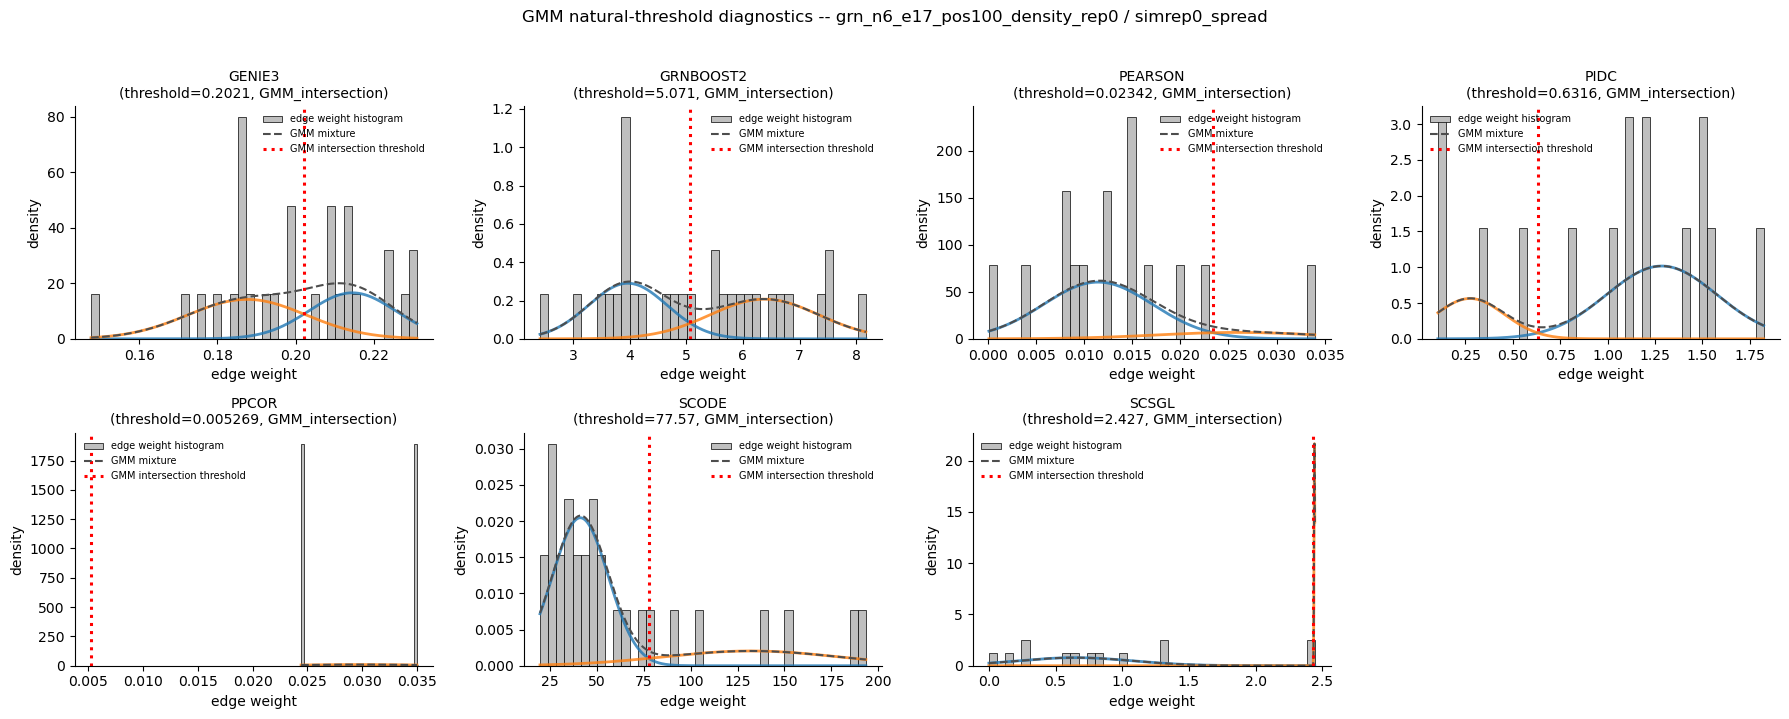

In [20]:
# Pick one representative (dataset, run) -- the one with the most algorithm subdirs
# available, so all 7 methods can be shown side by side.
_candidate_runs = []
for dataset_dir in sorted(BEELINE_OUTPUT_ROOT.iterdir()):
    if not dataset_dir.is_dir():
        continue
    for run_dir in sorted(dataset_dir.iterdir()):
        if not run_dir.is_dir() or not RUN_ID_RE.match(run_dir.name):
            continue
        algo_dirs = [d for d in run_dir.iterdir() if (d / "rankedEdges.csv").exists()]
        _candidate_runs.append((len(algo_dirs), dataset_dir.name, run_dir.name, algo_dirs))

_candidate_runs.sort(key=lambda t: t[0], reverse=True)
_, example_dataset, example_run, example_algo_dirs = _candidate_runs[0]
print(f"Using example dataset={example_dataset}, run={example_run}, "
      f"{len(example_algo_dirs)} method(s) available.")

n_methods = len(example_algo_dirs)
ncols = 4
nrows = int(np.ceil(n_methods / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 3.5 * nrows), squeeze=False)
axes_flat = axes.flatten()

for i, algo_dir in enumerate(sorted(example_algo_dirs, key=lambda d: d.name)):
    ranked_edges = pd.read_csv(algo_dir / "rankedEdges.csv", sep="\t", header=0)
    predicted = dedupe_predictions(ranked_edges)
    gmm, gmm_threshold, gmm_mode = fit_gmm_threshold(predicted["_abs"].values)
    plot_gmm_diagnostics(
        axes_flat[i], predicted["_abs"].values, gmm, gmm_mode,
        title=f"{algo_dir.name}\n(threshold={gmm_threshold:.4g}, {gmm_mode})",
    )

for j in range(n_methods, len(axes_flat)):
    axes_flat[j].axis("off")

fig.suptitle(f"GMM natural-threshold diagnostics -- {example_dataset} / {example_run}", y=1.02)
fig.tight_layout()
plt.show()


## Part 5 -- Combine into one long-form scores table

Reshapes both wide results tables into one common long-form schema
(`method`, `dataset_id`, `scheme`, `pool`, `metric_family`, `variant`, `score_name`, `value`)
so the heatmap code below has a single, uniform data source regardless of which method or
metric family it's rendering. For TwINFER, `pool` holds the 4 nested top-k candidate pools
within the `topk` family, and the 2 fan-out stages (`before_fan_out`/`after_fan_out`)
within the `natural` family; it's `"n/a"` everywhere else (BEELINE methods, and TwINFER's
own `auprc` family, which isn't pool-dependent). `scheme` is `"twinfer"` for TwINFER (it
isn't run through BEELINE's `spread`/`twin_paired` sampling schemes) and `spread`/
`twin_paired` for the other 7 methods.


In [21]:
VARIANT_SUFFIX = {"": "directed_unsigned", "_signed": "signed_directed", "_undirected": "undirected"}


def melt_beeline_wide(df):
    rows = []
    for _, r in df.iterrows():
        base = {"method": r["algorithm"], "dataset_id": r["dataset_id"], "scheme": r["scheme"], "pool": "n/a"}
        for suffix, variant in VARIANT_SUFFIX.items():
            rows.append({**base, "metric_family": "auprc", "variant": variant,
                         "score_name": "auprc", "value": r[f"auprc{suffix}"]})
            for score_name in ("precision", "recall", "f1"):
                rows.append({**base, "metric_family": "natural", "variant": variant,
                             "score_name": score_name, "value": r[f"{score_name}_natural{suffix}"]})
                rows.append({**base, "metric_family": "topk", "variant": variant,
                             "score_name": score_name, "value": r[f"{score_name}_topk{suffix}"]})
    return pd.DataFrame(rows)


def melt_twinfer_wide(df):
    rows = []
    for _, r in df.iterrows():
        base = {"method": "TwINFER", "dataset_id": r["dataset_id"], "scheme": "twinfer"}
        for suffix, variant in VARIANT_SUFFIX.items():
            rows.append({**base, "pool": "n/a", "metric_family": "auprc", "variant": variant,
                         "score_name": "auprc", "value": r[f"auprc{suffix}"]})
            for stage_name in NATURAL_FANOUT_STAGES:
                for score_name in ("precision", "recall", "f1"):
                    rows.append({**base, "pool": stage_name, "metric_family": "natural", "variant": variant,
                                 "score_name": score_name, "value": r[f"{score_name}_natural_{stage_name}{suffix}"]})
            for pool_name in TOPK_POOL_NAMES:
                for score_name in ("precision", "recall", "f1"):
                    rows.append({**base, "pool": pool_name, "metric_family": "topk", "variant": variant,
                                 "score_name": score_name, "value": r[f"{score_name}_topk_{pool_name}{suffix}"]})
    return pd.DataFrame(rows)


scores_long = pd.concat(
    [melt_twinfer_wide(twinfer_results_df), melt_beeline_wide(beeline_results_df)],
    ignore_index=True,
)
print(f"scores_long: {len(scores_long)} rows, methods = {sorted(scores_long['method'].unique())}")
scores_long.head()


scores_long: 57363 rows, methods = ['GENIE3', 'GRNBOOST2', 'PEARSON', 'PIDC', 'PPCOR', 'SCODE', 'SCSGL', 'TwINFER']


,method,dataset_id,scheme,pool,metric_family,variant,score_name,value
0,TwINFER,grn_n6_e17_pos100_density_rep0,twinfer,n/a,auprc,directed_unsigned,auprc,0.563211
1,TwINFER,grn_n6_e17_pos100_density_rep0,twinfer,before_fan_out,natural,directed_unsigned,precision,0.000000
2,TwINFER,grn_n6_e17_pos100_density_rep0,twinfer,before_fan_out,natural,directed_unsigned,recall,0.000000
3,TwINFER,grn_n6_e17_pos100_density_rep0,twinfer,before_fan_out,natural,directed_unsigned,f1,0.000000
4,TwINFER,grn_n6_e17_pos100_density_rep0,twinfer,after_fan_out,natural,directed_unsigned,precision,0.000000


## Part 6 -- Heatmaps

The only plot type in this notebook, per request. Style ported from
`evaluate_networksweep_final_beeline.ipynb`'s `plot_heatmap_by_algorithm_dataset`: rows =
method. TwINFER expands into multiple rows -- 4 (one per top-k candidate pool) within the
`topk` metric family, 2 (`before_fan_out`/`after_fan_out`) within the `natural` family --
directly showing the effect of fan-out removal at both the ranking (top-k) and hard-decision
(natural) level; elsewhere (`auprc`) it's a single row, folded into every BEELINE scheme
panel since it isn't run through `spread`/`twin_paired` sampling. Columns = dataset
(topology), averaged across technical replicates, plus an `Average` and `Rank` summary
column. One heatmap per (`metric_family`, `variant`, `score_name`, BEELINE `scheme`)
combination.


In [22]:
def _method_row_label(row):
    if row["method"] == "TwINFER" and row["metric_family"] in ("topk", "natural"):
        return f"TwINFER ({row['pool']})"
    return row["method"]


scores_long["method_label"] = scores_long.apply(_method_row_label, axis=1)

HEATMAP_CMAP = sns.color_palette("mako_r", as_cmap=True)
HEATMAP_SURFACE = "#fcfcfb"
INK_PRIMARY = "#0b0b0b"
GRIDLINE = "#e1e0d9"

DATASET_LABEL_RE = re.compile(
    r"^grn_n\d+_e(?P<e>\d+)(?:_pos(?P<pos>\d+))?_(?P<variant>density|sign_ratio|center)_rep(?P<rep>\d+)$"
)


def prettify_dataset_id(dataset_id: str) -> str:
    m = DATASET_LABEL_RE.match(dataset_id)
    if not m:
        return dataset_id
    pos_label = f"pos{m['pos']} " if m["variant"] == "sign_ratio" else ""
    return f"E{m['e']} {pos_label}{m['variant'].replace('_', ' ')} · r{m['rep']}"


def _label_color_for(val, norm, cmap):
    r, g, b, _ = cmap(norm(val))
    luminance = 0.299 * r + 0.587 * g + 0.114 * b
    return "#ffffff" if luminance < 0.6 else INK_PRIMARY


def plot_heatmap_by_method_dataset(subset, value_col="value", ax=None, title=None):
    """
    Rows = method_label, columns = dataset_id (mean across technical replicates/sim_reps),
    plus Average and Rank summary columns -- ported from
    evaluate_networksweep_final_beeline.ipynb's plot_heatmap_by_algorithm_dataset.
    """
    pivot = subset.groupby(["method_label", "dataset_id"])[value_col].mean().unstack("dataset_id")
    if pivot.empty:
        return None

    row_avg = pivot.mean(axis=1)
    row_rank = row_avg.rank(ascending=False, method="min").astype(int)
    pivot = pivot.loc[row_avg.sort_values(ascending=False).index]
    row_avg = row_avg.loc[pivot.index]
    row_rank = row_rank.loc[pivot.index]

    n_dataset_cols = pivot.shape[1]
    own_ax = ax is None
    if own_ax:
        fig, ax = plt.subplots(figsize=(0.6 * (n_dataset_cols + 2) + 3, 0.4 * len(pivot.index) + 4))

    finite_vals = pivot.values[~pd.isna(pivot.values)]
    vmax = float(finite_vals.max()) if finite_vals.size else 1.0
    norm = Normalize(vmin=0.0, vmax=max(vmax, 1e-9))

    grid = np.hstack([
        pivot.values,
        row_avg.values.reshape(-1, 1),
        np.full((len(pivot), 1), np.nan),
    ])

    display_cmap = HEATMAP_CMAP.copy()
    display_cmap.set_bad(HEATMAP_SURFACE)
    im = ax.imshow(grid, cmap=display_cmap, aspect="auto", norm=norm)

    for i in range(grid.shape[0]):
        for j in range(n_dataset_cols + 1):
            val = grid[i, j]
            if pd.isna(val):
                continue
            label_color = _label_color_for(val, norm, HEATMAP_CMAP)
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=10, color=label_color)
        ax.text(n_dataset_cols + 1, i, f"#{row_rank.iloc[i]}", ha="center", va="center",
                fontsize=10, color=INK_PRIMARY)

    ax.axvline(n_dataset_cols - 0.5, color=GRIDLINE, linewidth=1.5)
    ax.set_xticks(range(grid.shape[1]))
    ax.set_xticklabels([prettify_dataset_id(c) for c in pivot.columns] + ["Average", "Rank"],
                       rotation=45, ha="right", color=INK_PRIMARY, fontsize=9)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, color=INK_PRIMARY, fontsize=10)
    ax.set_title(title or "", color=INK_PRIMARY, fontsize=13)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(length=0)

    if own_ax:
        fig.colorbar(im, ax=ax, shrink=0.8, label=value_col)
        fig.tight_layout()
        return fig
    return im


### Fan-out pairs detected per network

Before comparing performance, a quick look at how many shared-regulator confound pairs
`separate_fan_outs_from_mutual_regulation` actually found: `n_fan_out_pairs` (both
directions discarded as a fan-out artifact) vs `n_mutual_regulation_pairs` (both
directions kept -- confirmed as genuine reciprocal regulation) per network, mean across
technical replicates.


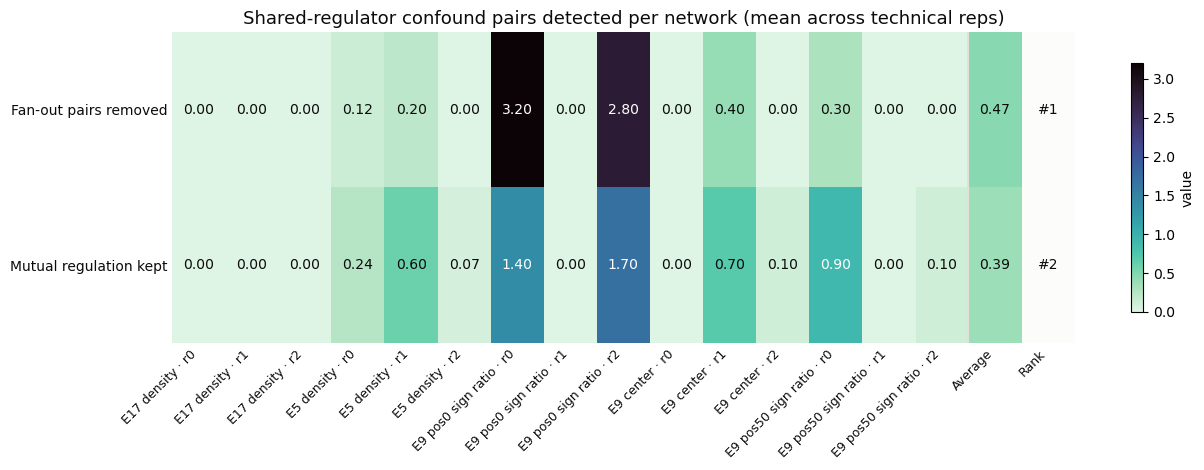

In [61]:
fan_out_counts_long = twinfer_results_df.melt(
    id_vars=["dataset_id"],
    value_vars=["n_fan_out_pairs", "n_mutual_regulation_pairs"],
    var_name="method_label", value_name="value",
)
fan_out_counts_long["method_label"] = fan_out_counts_long["method_label"].map({
    "n_fan_out_pairs": "Fan-out pairs removed",
    "n_mutual_regulation_pairs": "Mutual regulation kept",
})

fig = plot_heatmap_by_method_dataset(
    fan_out_counts_long,
    title="Shared-regulator confound pairs detected per network (mean across technical reps)",
)
if fig is not None:
    plt.show()


In [ ]:
METRIC_FAMILIES = {
    "auprc": ["auprc"],
    "natural": ["precision", "recall", "f1"],
    "topk": ["precision", "recall", "f1"],
}
VARIANTS = ["directed_unsigned", "signed_directed"]
SCHEMES = ["twin_paired"]

for metric_family, score_names in METRIC_FAMILIES.items():
    for score_name in score_names:
        for variant in VARIANTS:
            for scheme in SCHEMES:
                subset = scores_long[
                    (scores_long["metric_family"] == metric_family)
                    & (scores_long["score_name"] == score_name)
                    & (scores_long["variant"] == variant)
                    & ((scores_long["scheme"] == scheme) | (scores_long["method"] == "TwINFER"))
                ]
                if subset.empty:
                    print("empty")
                    continue
                fig = plot_heatmap_by_method_dataset(
                    subset,
                    title=f"{metric_family} -- {score_name} -- {variant.replace('_', ' ')}",
                )
                if fig is not None:
                    plt.show()


In [29]:
def count_ground_truth_fanouts_sweep(network_dir, suffix=".txt"):
    """Ground-truth fan-out pair count per topology (find_confounded_pairs), keyed by
    the same dataset_id convention as twinfer_results_df/beeline_results_df."""
    records = []
    for path in glob.glob(os.path.join(network_dir, f"*{suffix}")):
        dataset_id = os.path.basename(path).replace(suffix, "")
        gt = load_ground_truth_matrix(path)
        fanout_pairs = find_confounded_pairs(gt, list(gt.index))
        records.append({"dataset_id": dataset_id, "n_ground_truth_fanout_pairs": len(fanout_pairs)})
    return pd.DataFrame(records)


gt_fanout_df = count_ground_truth_fanouts_sweep(path_to_ground_truth_dir)

# Same (metric_family, score_name) pairs and variant/scheme values the Part 6 loop below
# iterates over -- keep these in sync with METRIC_FAMILIES/VARIANTS/SCHEMES in that cell.
_METRIC_FAMILY_SCORE_NAMES = {
    "auprc": ["auprc"],
    "natural": ["precision", "recall", "f1"],
    "topk": ["precision", "recall", "f1"],
}
_VARIANTS = ["directed_unsigned", "signed_directed"]
_SCHEMES = ["twin_paired"]

panel_combos = pd.DataFrame([
    {"metric_family": mf, "score_name": sn, "variant": v, "scheme": s}
    for mf, score_names in _METRIC_FAMILY_SCORE_NAMES.items()
    for sn in score_names
    for v in _VARIANTS
    for s in _SCHEMES
])

gt_rows = panel_combos.merge(gt_fanout_df, how="cross")
gt_rows["method"] = "Ground truth"
gt_rows["pool"] = "n/a"
gt_rows["method_label"] = "Ground truth fan-out pairs"
gt_rows = gt_rows.rename(columns={"n_ground_truth_fanout_pairs": "value"})

scores_long = pd.concat([scores_long, gt_rows], ignore_index=True)
print(f"Added {len(gt_rows)} ground-truth fan-out rows across {panel_combos.shape[0]} panel(s).")

Added 210 ground-truth fan-out rows across 14 panel(s).


In [27]:
def _plot_fanout_strip(ax, fanout_pivot, dataset_order, cmap_name="Greys"):
    """Single/few-row strip for raw-count rows (e.g. ground-truth fan-out pairs),
    rendered on its own grayscale color scale -- independent of the main heatmap's
    colormap/normalization, since counts and 0-1 scores aren't comparable."""
    fanout_pivot = fanout_pivot.reindex(columns=dataset_order)
    row_avg = fanout_pivot.mean(axis=1)
    n_cols = fanout_pivot.shape[1]

    # Extra trailing NaN column mirrors the main heatmap's "Rank" column so the two
    # panels' dataset columns stay pixel-aligned, even though this strip has no rank.
    grid = np.hstack([
        fanout_pivot.values,
        row_avg.values.reshape(-1, 1),
        np.full((len(fanout_pivot), 1), np.nan),
    ])

    finite_vals = grid[~pd.isna(grid)]
    vmax = float(finite_vals.max()) if finite_vals.size else 1.0
    norm = Normalize(vmin=0.0, vmax=max(vmax, 1e-9))

    cmap = plt.get_cmap(cmap_name)
    display_cmap = cmap.copy()
    display_cmap.set_bad(HEATMAP_SURFACE)
    im = ax.imshow(grid, cmap=display_cmap, aspect="auto", norm=norm)

    for i in range(grid.shape[0]):
        for j in range(n_cols + 1):  # data cols + Average, skip the blank alignment col
            val = grid[i, j]
            if pd.isna(val):
                continue
            r, g, b, _ = cmap(norm(val))
            luminance = 0.299 * r + 0.587 * g + 0.114 * b
            color = "#ffffff" if luminance < 0.6 else INK_PRIMARY
            ax.text(j, i, f"{val:.0f}", ha="center", va="center", fontsize=10, color=color)

    ax.axvline(n_cols - 0.5, color=GRIDLINE, linewidth=1.5)
    ax.set_xticks(range(grid.shape[1]))
    ax.set_xticklabels([prettify_dataset_id(c) for c in fanout_pivot.columns] + ["Average", ""],
                        rotation=45, ha="right", color=INK_PRIMARY, fontsize=9)
    ax.set_yticks(range(len(fanout_pivot.index)))
    ax.set_yticklabels(fanout_pivot.index, color=INK_PRIMARY, fontsize=10)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(length=0)
    return im


def plot_heatmap_with_fanout_row(subset, fanout_label="Ground truth fan-out pairs",
                                  value_col="value", title=None):
    """
    Same layout/rows as plot_heatmap_by_method_dataset for the actual methods, plus a
    second, independently-colored strip underneath for the ground-truth fan-out row (if
    present in `subset`) -- separate colorbar/scale since it's a raw count, not a 0-1 score.
    """
    is_fanout = subset["method_label"] == fanout_label
    main_subset = subset[~is_fanout]
    fanout_subset = subset[is_fanout]
    if main_subset.empty:
        return None

    if fanout_subset.empty:
        fig = plot_heatmap_by_method_dataset(main_subset, value_col=value_col, title=title)
        return fig

    main_pivot = main_subset.groupby(["method_label", "dataset_id"])[value_col].mean().unstack("dataset_id")
    row_avg = main_pivot.mean(axis=1)
    main_pivot = main_pivot.loc[row_avg.sort_values(ascending=False).index]
    dataset_order = main_pivot.columns.tolist()

    n_main_rows = len(main_pivot)
    fanout_pivot = fanout_subset.groupby(["method_label", "dataset_id"])[value_col].mean().unstack("dataset_id")
    n_fanout_rows = len(fanout_pivot)

    fig = plt.figure(figsize=(0.6 * (len(dataset_order) + 2) + 3,
                               0.4 * (n_main_rows + n_fanout_rows) + 5))
    gs = fig.add_gridspec(2, 1, height_ratios=[n_main_rows, n_fanout_rows], hspace=0.35)

    ax_main = fig.add_subplot(gs[0])
    im_main = plot_heatmap_by_method_dataset(main_subset, value_col=value_col, ax=ax_main)
    fig.colorbar(im_main, ax=ax_main, shrink=0.8, label=value_col)
    ax_main.set_title(title or "", color=INK_PRIMARY, fontsize=13)
    ax_main.set_xticklabels([])  # dataset labels shown once, on the bottom strip only

    ax_fanout = fig.add_subplot(gs[1])
    im_fanout = _plot_fanout_strip(ax_fanout, fanout_pivot, dataset_order)
    fig.colorbar(im_fanout, ax=ax_fanout, shrink=0.8, label="fan-out pair count")

    return fig

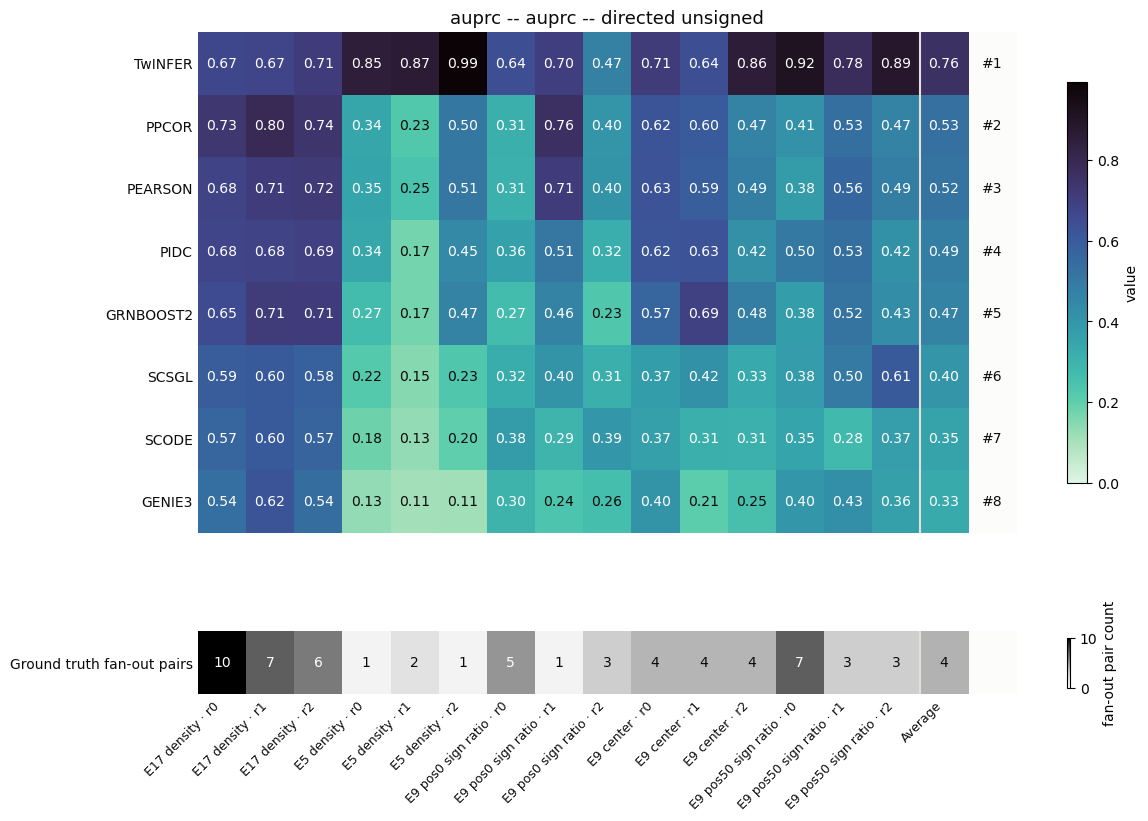

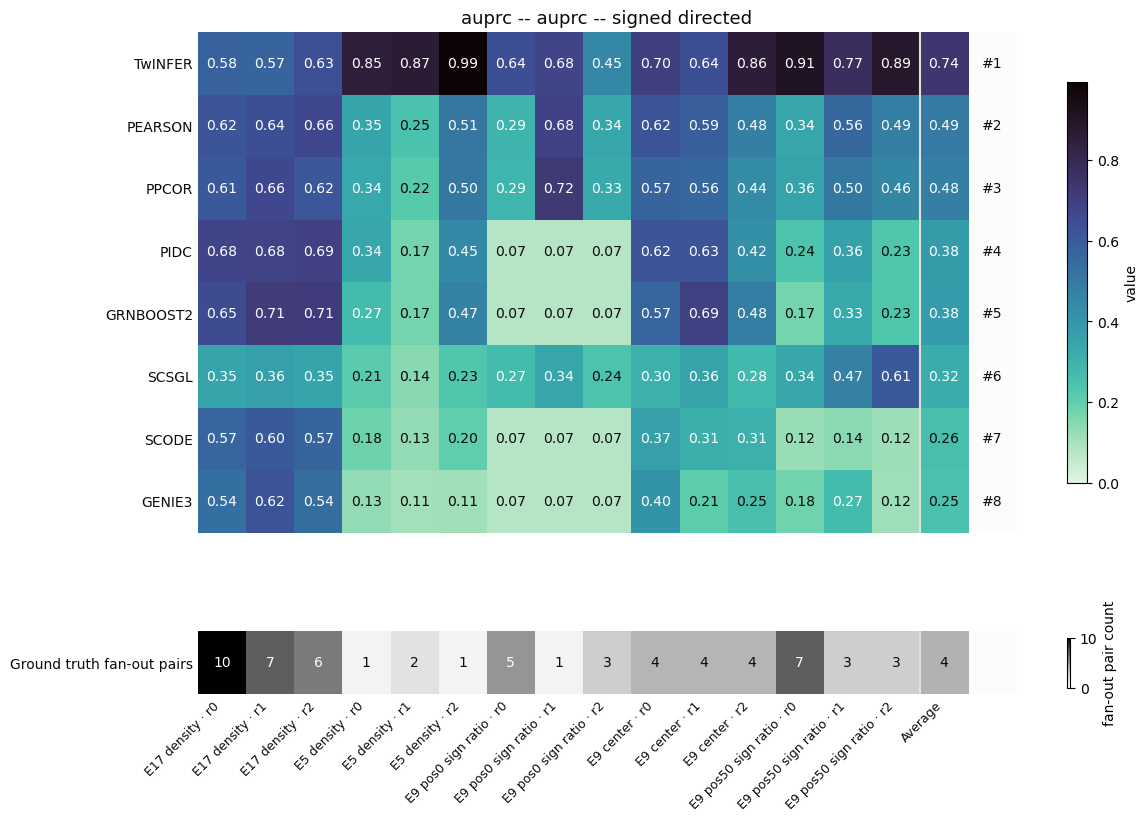

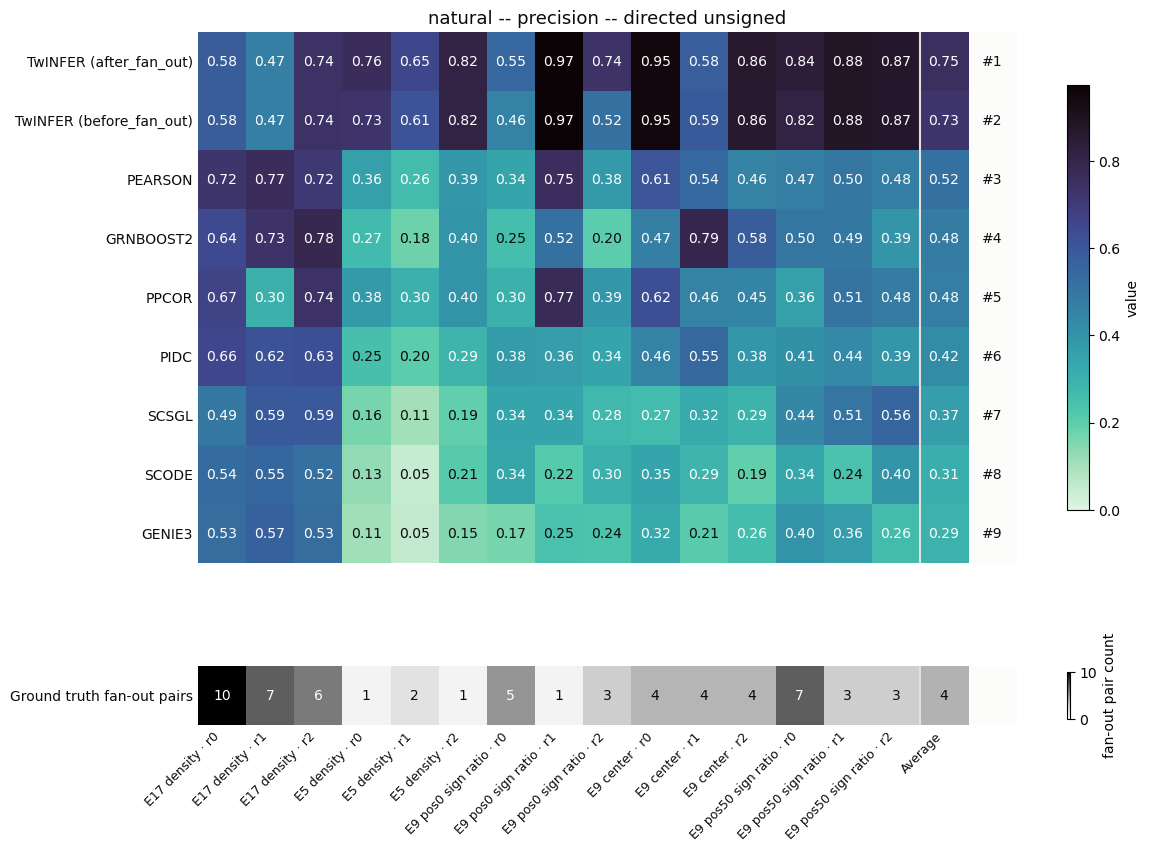

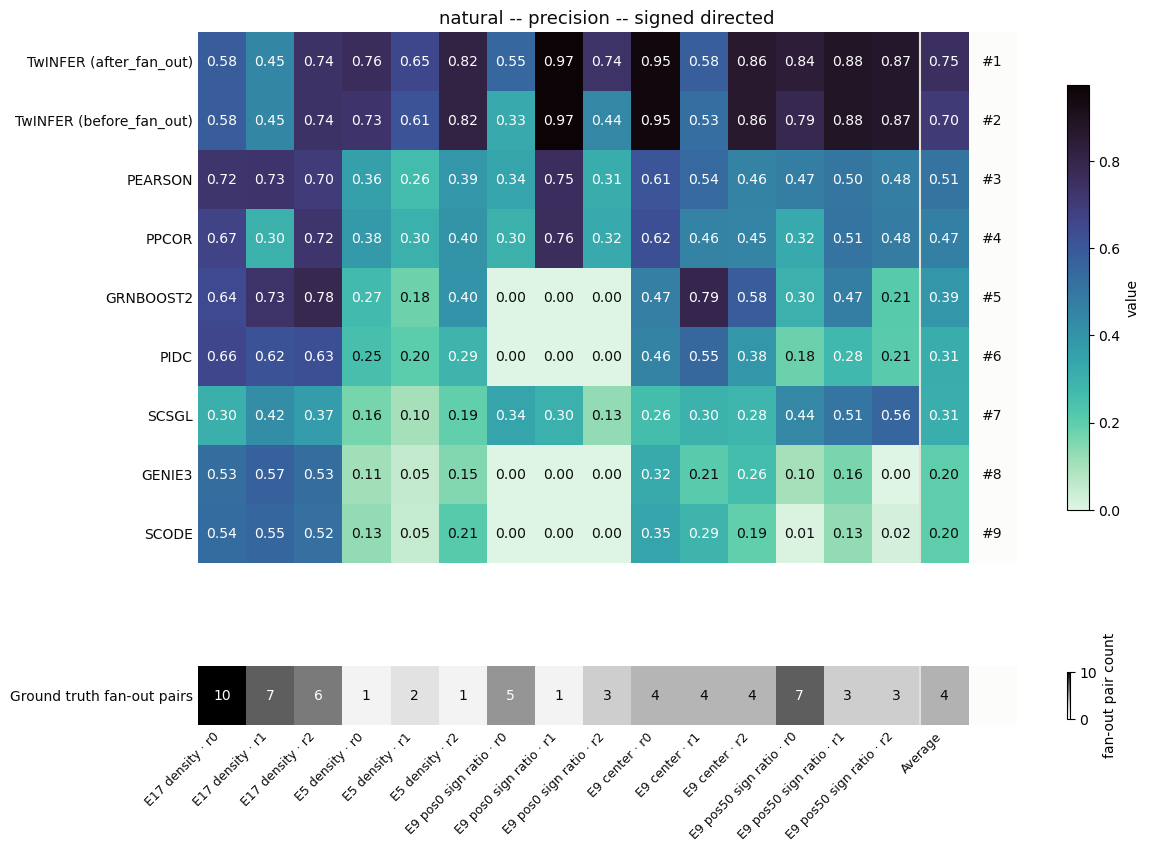

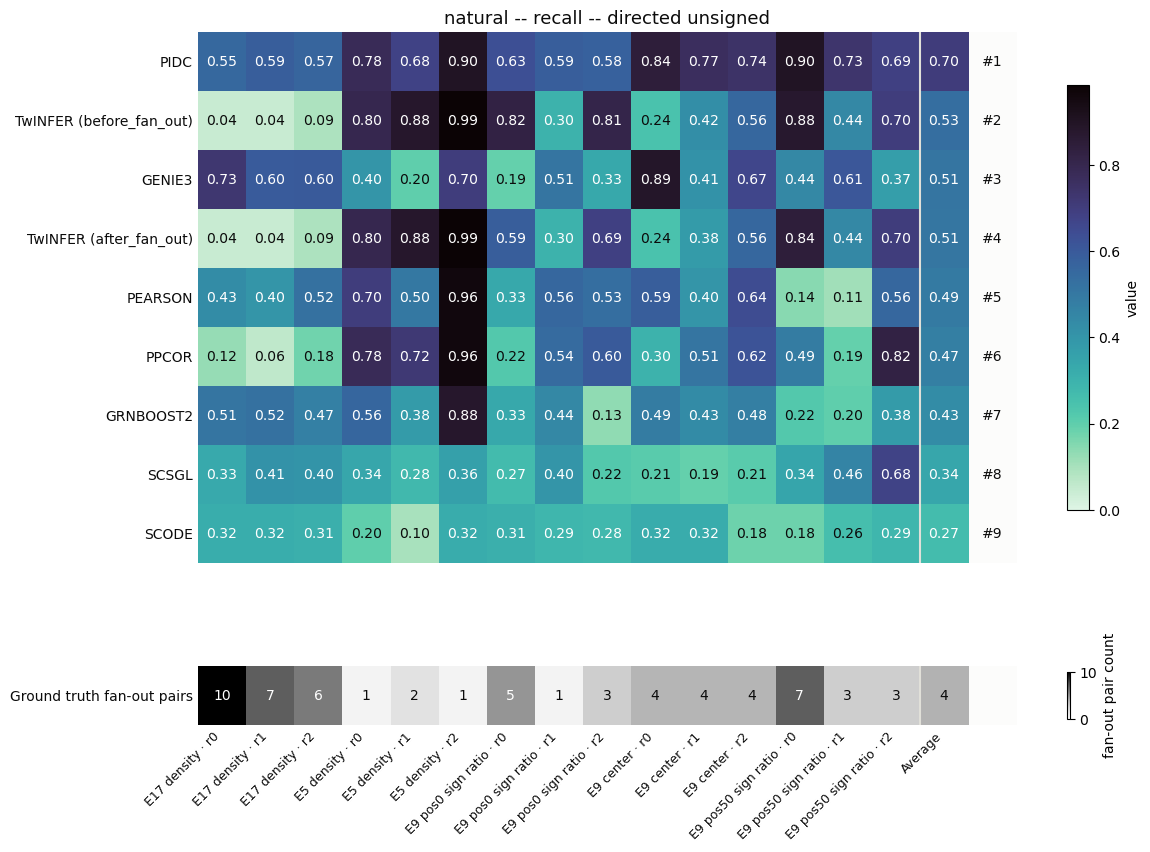

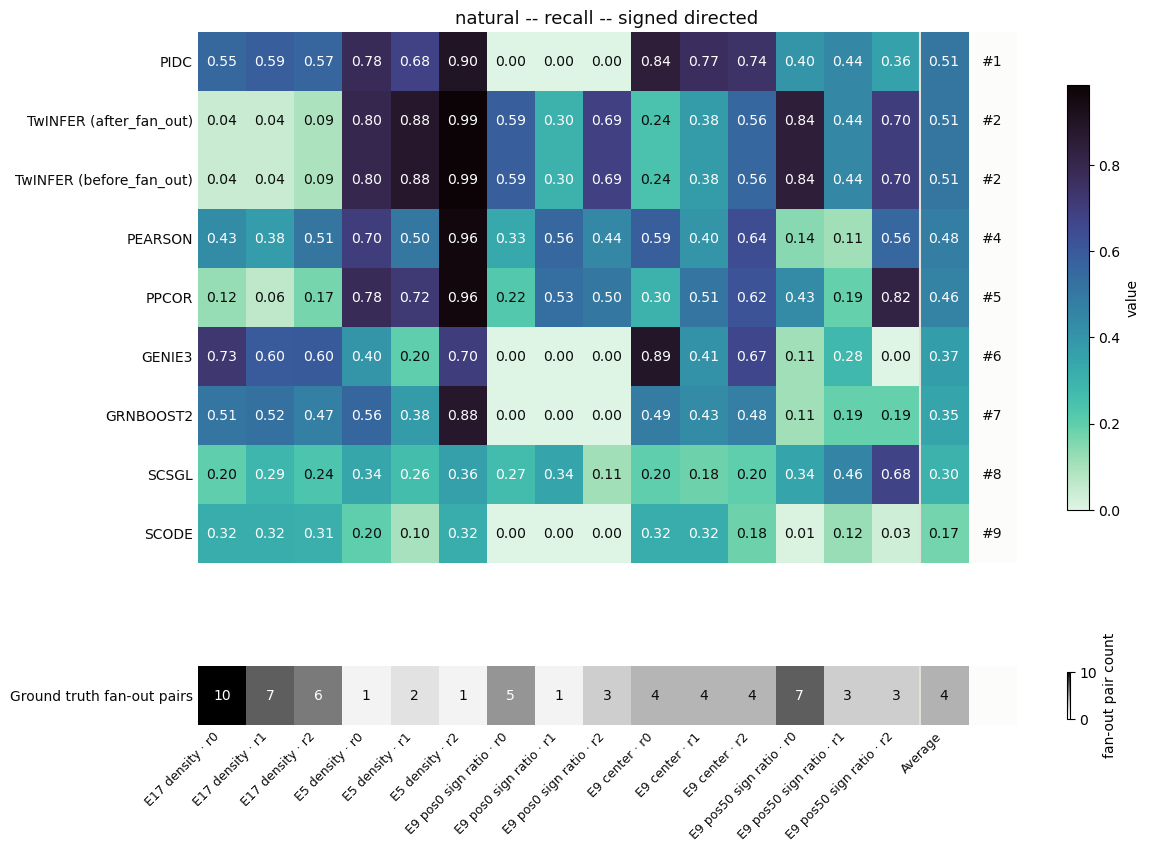

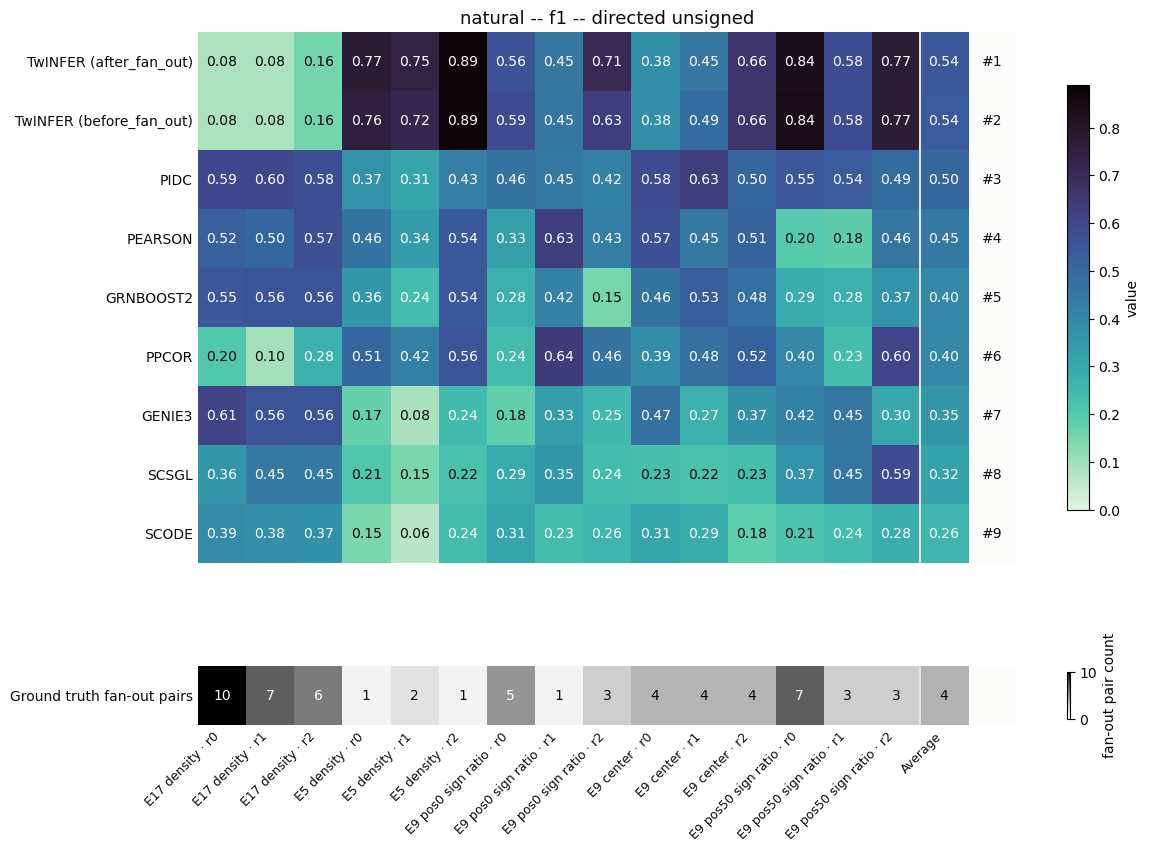

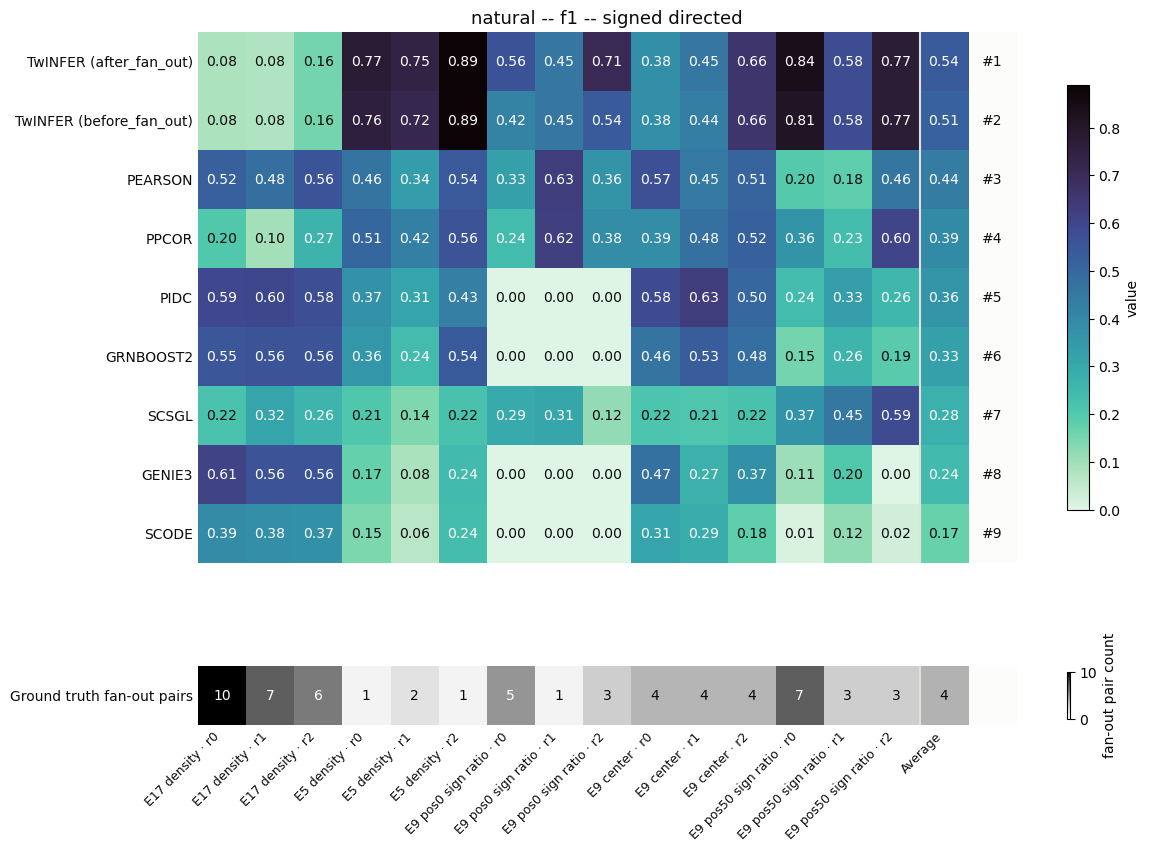

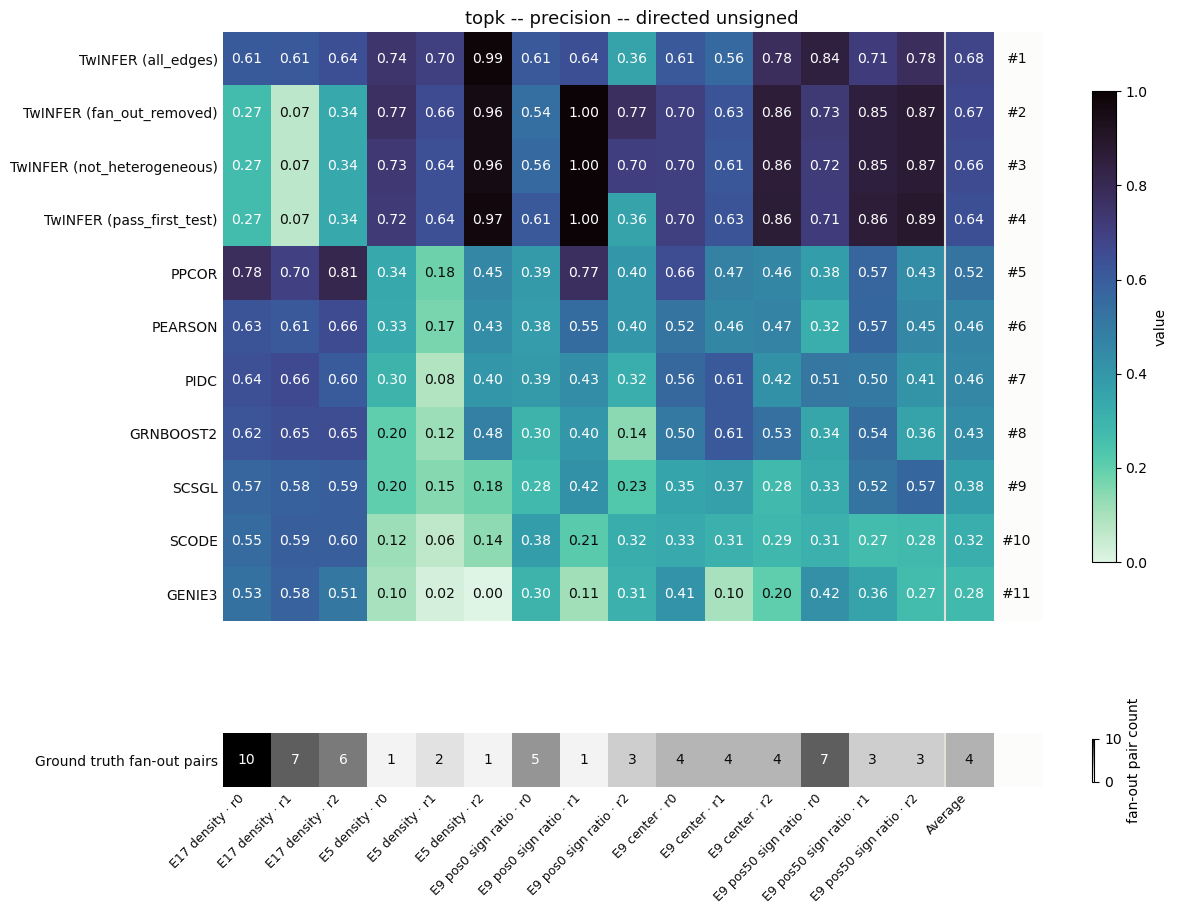

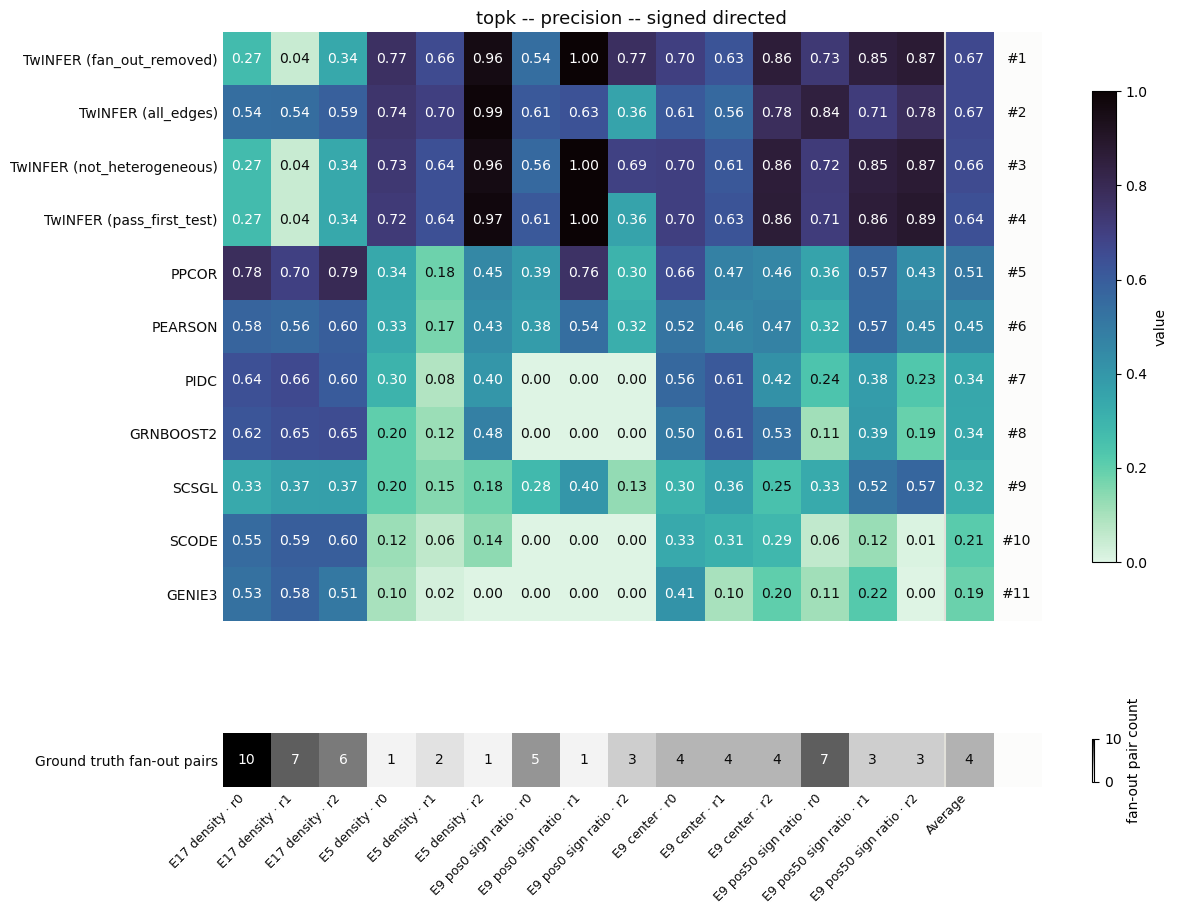

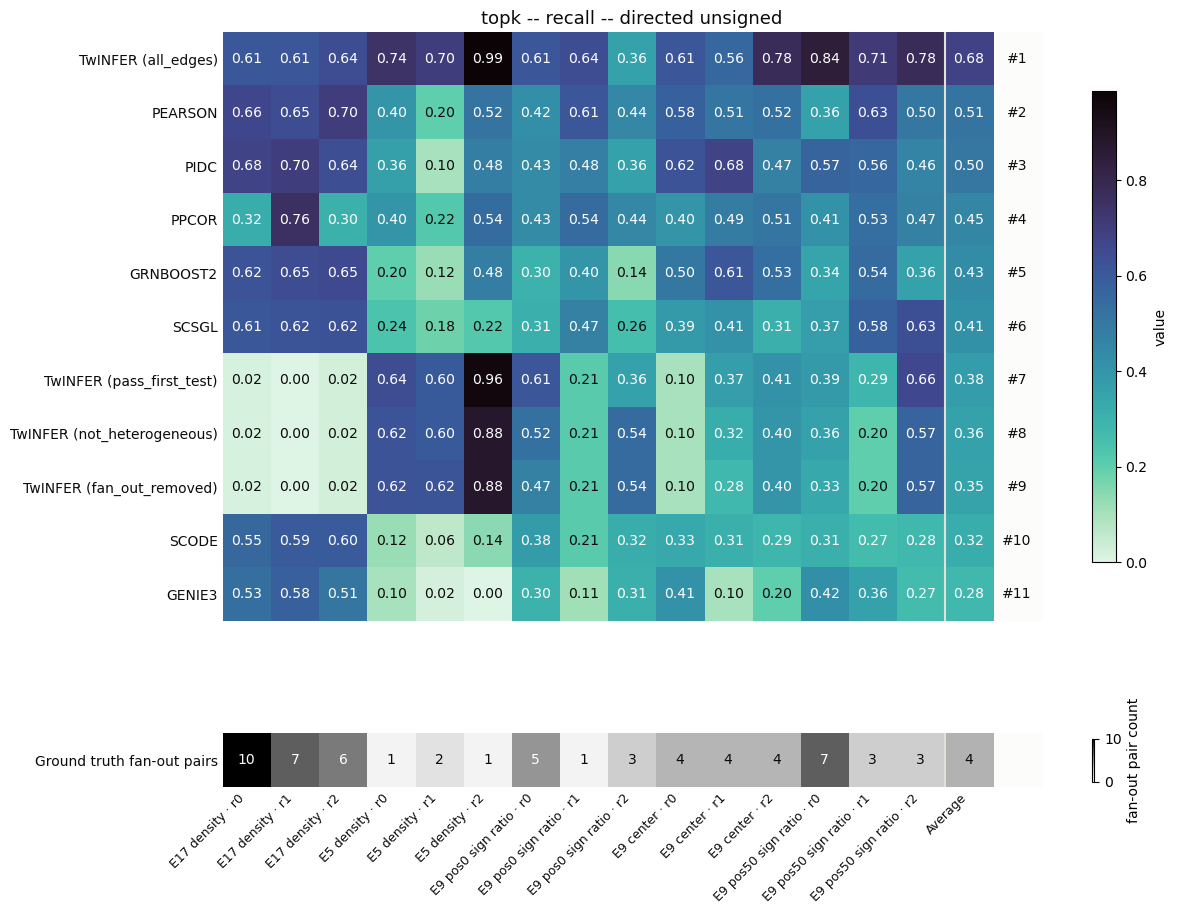

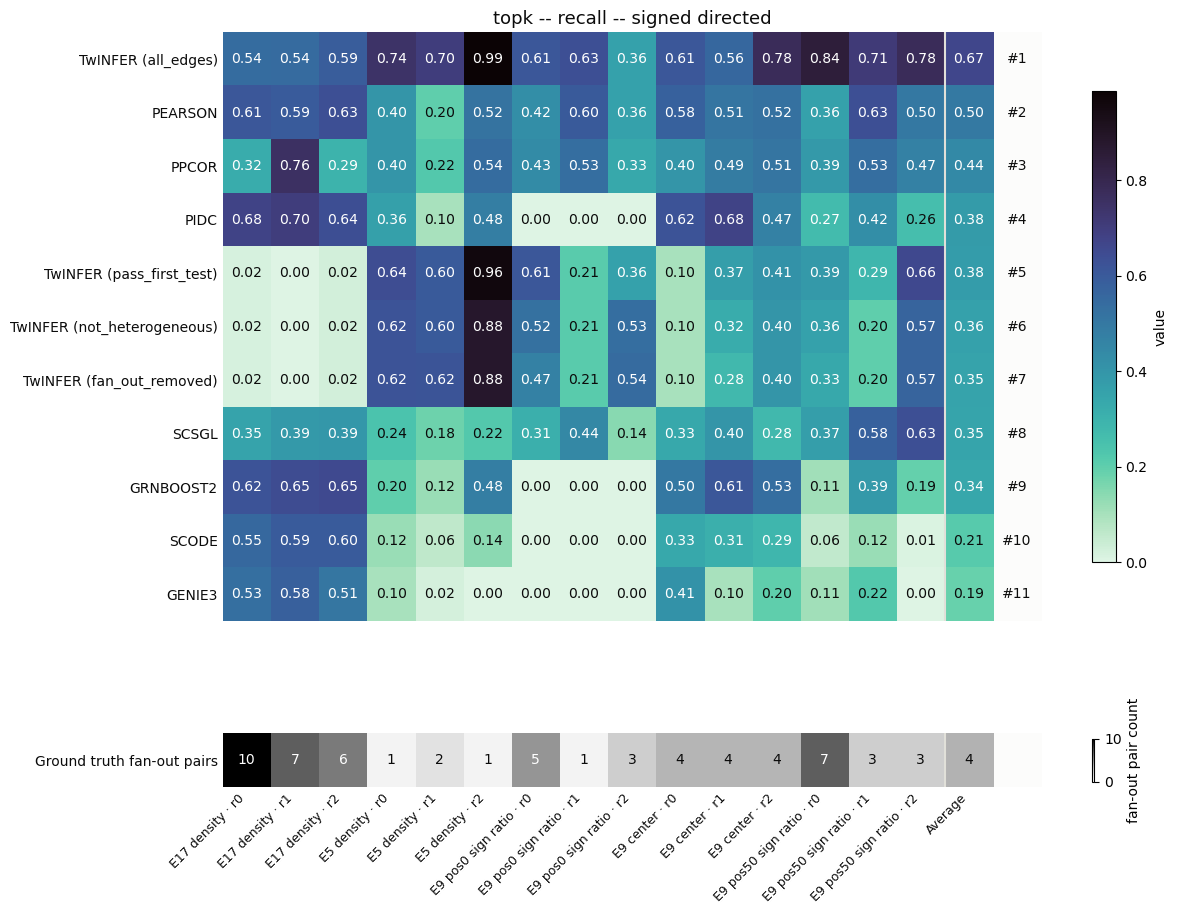

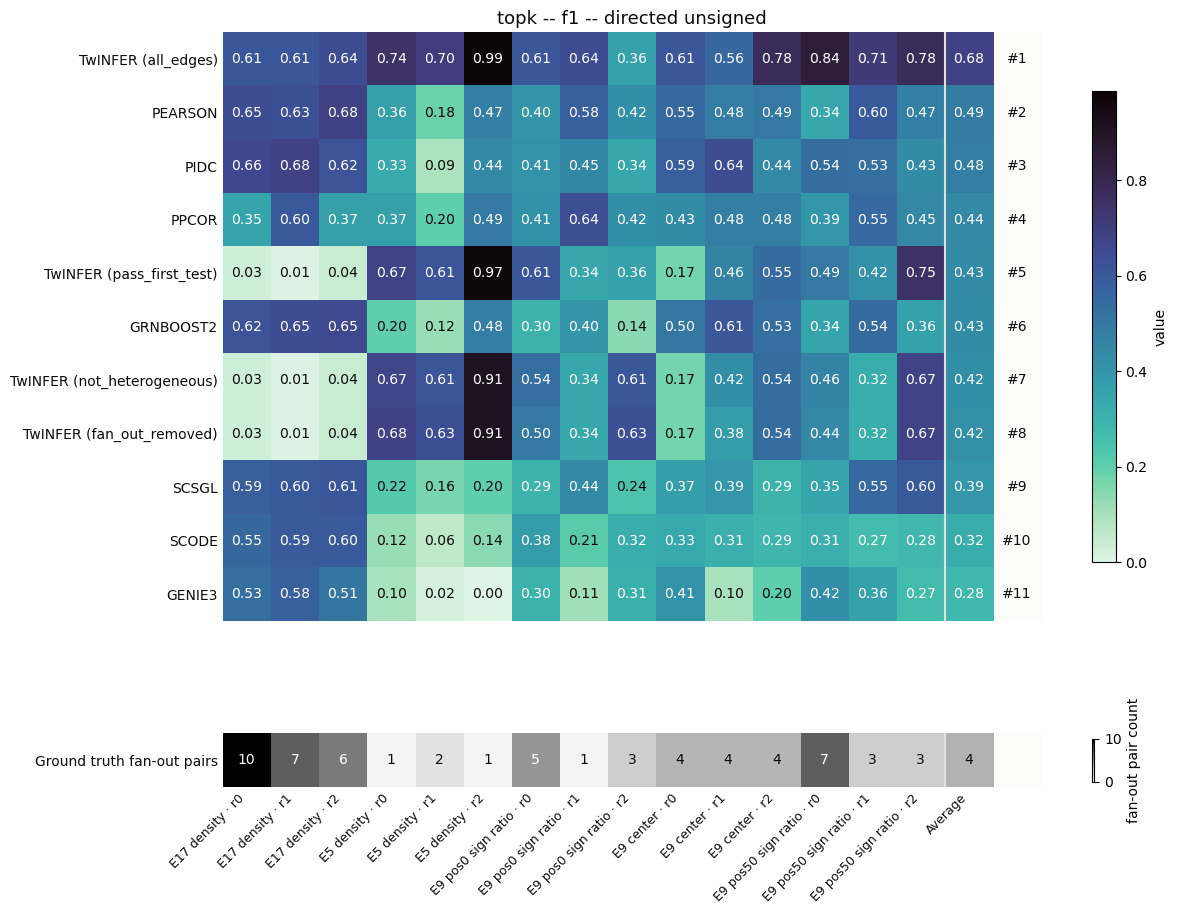

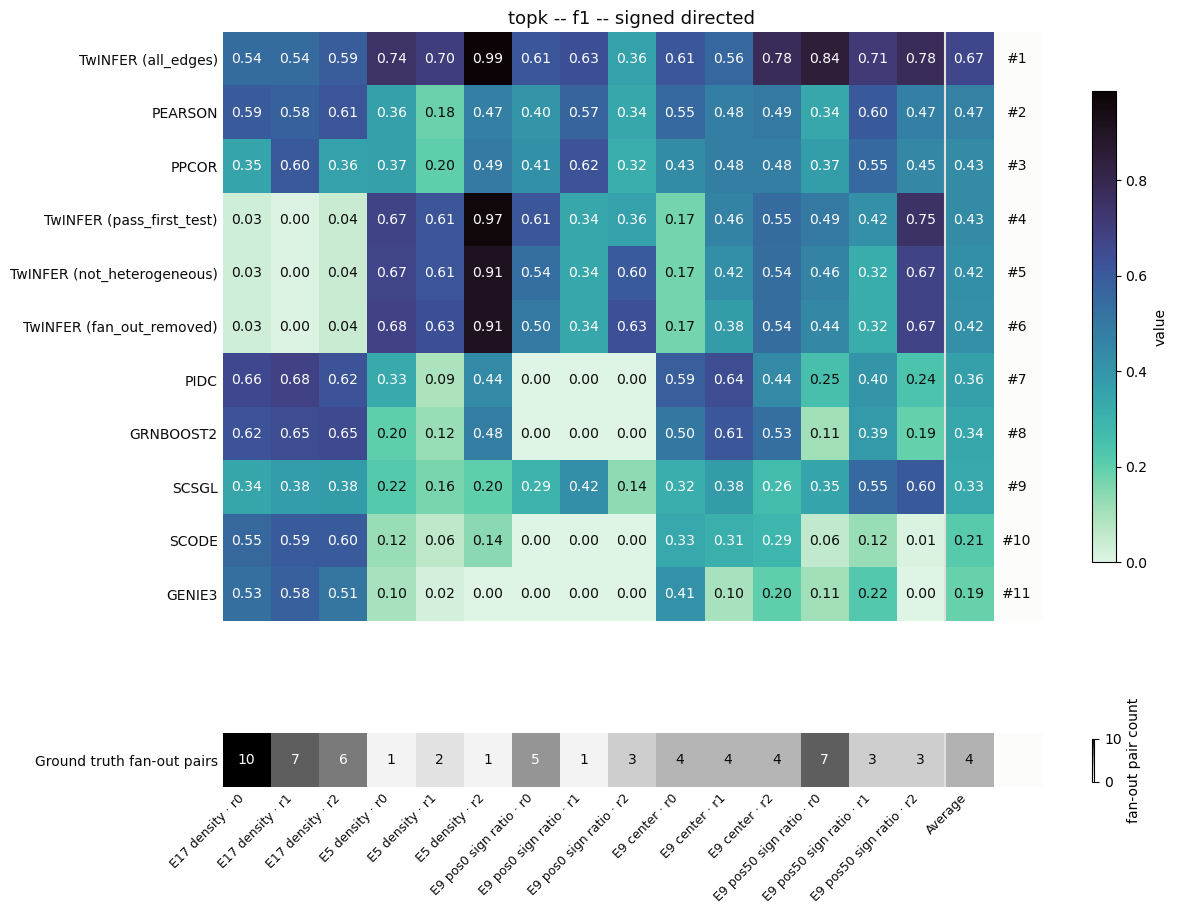

In [30]:
METRIC_FAMILIES = {
    "auprc": ["auprc"],
    "natural": ["precision", "recall", "f1"],
    "topk": ["precision", "recall", "f1"],
}
VARIANTS = ["directed_unsigned", "signed_directed"]
SCHEMES = ["twin_paired"]

for metric_family, score_names in METRIC_FAMILIES.items():
    for score_name in score_names:
        for variant in VARIANTS:
            for scheme in SCHEMES:
                subset = scores_long[
                    (scores_long["metric_family"] == metric_family)
                    & (scores_long["score_name"] == score_name)
                    & (scores_long["variant"] == variant)
                    & ((scores_long["scheme"] == scheme) | (scores_long["method"] == "TwINFER")
                       | (scores_long["method"] == "Ground truth"))
                ]
                if subset.empty:
                    print("empty")
                    continue
                fig = plot_heatmap_with_fanout_row(
                    subset,
                    title=f"{metric_family} -- {score_name} -- {variant.replace('_', ' ')}",
                )
                if fig is not None:
                    plt.show()